# TAHAP 1

### Subbab 1.1 — Proses inti

Bagian ini menjalankan: instal pustaka yang dibutuhkan.


In [1]:
# Instal pustaka yang dibutuhkan
!pip install pandas pdfminer.six openpyxl > /dev/null 2>&1
print('✅ Pustaka berhasil diinstal.')

✅ Pustaka berhasil diinstal.


### Subbab 1.2 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [2]:
import io
import os
import re
import time
from datetime import date
import pandas as pd
from pdfminer import high_level  # Untuk ekstraksi teks PDF
# from google.colab import drive

### Subbab 1.3 — Proses inti

Bagian ini menjalankan: hubungkan Google Drive.


In [3]:
# Hubungkan Google Drive
# drive.mount('/content/drive')

Mounted at /content/drive


### Subbab 1.4 — Konfigurasi path dan parameter

Mengatur path, parameter, dan variabel penting sebelum proses dijalankan.


In [4]:
# --- Bagian Konfigurasi ---
# !!! PENTING: SESUAIKAN PATH INI DENGAN FOLDER GOOGLE DRIVE ANDA !!!
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path

# Kata kunci untuk penamaan file output
KEYWORD_FOR_FILENAMING = "Pajak"

# Definisikan path
PATH_RAW_TEXT_OUTPUT    = os.path.join(BASE_DRIVE_PATH, "data/raw")
PATH_PDF_DOWNLOAD       = os.path.join(BASE_DRIVE_PATH, "PDFs_Putusan")  # ← TARUH PDF MANUAL DI SINI
PATH_INITIAL_SCRAPER_CSV = os.path.join(BASE_DRIVE_PATH, "Scraper_CSVs")
PATH_LOGS               = os.path.join(BASE_DRIVE_PATH, "logs")

# Buat direktori jika belum ada
os.makedirs(PATH_RAW_TEXT_OUTPUT, exist_ok=True)
os.makedirs(PATH_PDF_DOWNLOAD, exist_ok=True)
os.makedirs(PATH_INITIAL_SCRAPER_CSV, exist_ok=True)
os.makedirs(PATH_LOGS, exist_ok=True)

CLEANING_LOG_FILE = os.path.join(PATH_LOGS, "cleaning.log")
print(f'✅ Konfigurasi path selesai. Folder PDF: {PATH_PDF_DOWNLOAD}')

✅ Konfigurasi path selesai. Folder PDF: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/PDFs_Putusan


### Subbab 1.5 — Definisi beberapa fungsi

Mendefinisikan beberapa fungsi utama yang dipakai pada tahap ini.


In [5]:
def log_cleaning_action(message, level="INFO"):
    """Menambahkan pesan ke file log pembersihan dengan level."""
    import time
    timestamp = time.strftime('%Y-%m-%d %H:%M:%S')
    log_line = f"{timestamp} [{level}] {message}"
    try:
        with open(CLEANING_LOG_FILE, "a", encoding="utf-8") as f:
            f.write(log_line + "\n")
    except Exception:
        pass  # fail silently if log file not writable
    print(message)


def basic_text_cleaning_ma(text):
    """Pembersihan teks dasar untuk dokumen Mahkamah Agung."""
    if not isinstance(text, str):
        return ""
    text = text.replace("M a h ka m a h A g u n g R e p u blik In d o n esia\n", "")
    text = text.replace("Disclaimer\n", "")
    text = text.replace(
        "Kepaniteraan Mahkamah Agung Republik Indonesia berusaha untuk selalu mencantumkan "
        "informasi paling kini dan akurat sebagai bentuk komitmen Mahkamah Agung untuk "
        "pelayanan publik, transparansi dan akuntabilitas\n", " "
    )
    text = text.replace(
        "pelaksanaan fungsi peradilan. Namun dalam hal-hal tertentu masih dimungkinkan "
        "terjadi permasalahan teknis terkait dengan akurasi dan keterkinian informasi yang "
        "kami sajikan, hal mana akan terus kami perbaiki dari waktu kewaktu.\n", ""
    )
    text = text.replace(
        "Dalam hal Anda menemukan inakurasi informasi yang termuat pada situs ini atau "
        "informasi yang seharusnya ada, namun belum tersedia, maka harap segera hubungi "
        "Kepaniteraan Mahkamah Agung RI melalui :\n", ""
    )
    text = text.replace("Email : kepaniteraan@mahkamahagung.go.id Telp : 021-384 3348 (ext.318)\n", "")
    text = re.sub(r'\s+', ' ', text).strip()
    log_cleaning_action("Performed basic text cleaning (MA disclaimers, whitespace).")
    return text


def convert_pdf_to_cleaned_text(pdf_path_or_stream):
    """Mengekstrak teks dari PDF (path file atau BytesIO) dan menerapkan pembersihan."""
    try:
        raw_text = high_level.extract_text(pdf_path_or_stream)
        return basic_text_cleaning_ma(raw_text)
    except Exception as e:
        log_cleaning_action(f"Error ekstraksi teks PDF: {e}", level="ERROR")
        return ""


print('\u2705 Fungsi pembersihan teks berhasil didefinisikan.')


✅ Fungsi pembersihan teks berhasil didefinisikan.


### Subbab 1.6 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [6]:
# List global untuk menyimpan semua data hasil ekstraksi ke satu CSV akhir
all_extracted_data = []
print('✅ Variabel global diinisialisasi.')

✅ Variabel global diinisialisasi.


### Subbab 1.7 — Definisi fungsi `extract_pdf_from_folder`

Mendefinisikan fungsi utama untuk membaca PDF yang sudah diunduh secara manual dari folder `PDFs_Putusan`.


In [7]:
def extract_metadata_from_text(text):
    """
    Mengekstrak metadata dasar dari teks putusan pajak menggunakan regex.
    Mengembalikan dict berisi nomor perkara, tanggal, amar, dll.
    """
    meta = {
        "nomor_perkara": "",
        "tanggal_putusan": "",
        "jenis_perkara": "Pajak",
        "lembaga_peradilan": "",
        "amar_putusan": "",
    }

    # Nomor perkara
    m = re.search(
        r'(?:Nomor|No\.?)\s*[:\.]?\s*([\w\s\/\.\-]+(?:PAJAK|PJK|B|PUT|K|P)[\w\s\/\.\-]+)',
        text, re.IGNORECASE
    )
    if m:
        meta["nomor_perkara"] = m.group(1).strip()[:80]

    # Tanggal putusan
    m = re.search(
        r'(?:dibacakan|diucapkan|ditetapkan|tanggal)[^\n]{0,30}?'
        r'(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})',
        text, re.IGNORECASE
    )
    if m:
        meta["tanggal_putusan"] = m.group(1).strip()

    # Lembaga peradilan
    m = re.search(
        r'(Mahkamah Agung|Pengadilan Pajak|Pengadilan Tinggi[^,\n]*|Pengadilan Negeri[^,\n]*)',
        text, re.IGNORECASE
    )
    if m:
        meta["lembaga_peradilan"] = m.group(1).strip()

    # Amar putusan (sederhana)
    m = re.search(
        r'MENGADILI,?\s*(.*?)(?:Demikianlah|Memperhatikan pasal)',
        text, re.IGNORECASE | re.DOTALL
    )
    if m:
        meta["amar_putusan"] = re.sub(r'\s+', ' ', m.group(1)).strip()[:300]

    return meta


def extract_pdf_from_folder(pdf_folder_path):
    """
    Membaca semua file PDF dari folder pdf_folder_path,
    mengekstrak teks dan metadata, lalu menyimpan ke file .txt dan list global.
    Menggantikan proses scraping otomatis.
    """
    global all_extracted_data

    pdf_files = [
        f for f in os.listdir(pdf_folder_path)
        if f.lower().endswith('.pdf')
    ]

    if not pdf_files:
        print(f'⚠️  Tidak ada file PDF ditemukan di: {pdf_folder_path}')
        print('    Silakan taruh file PDF putusan ke folder tersebut, lalu jalankan ulang sel ini.')
        return

    print(f'📂 Ditemukan {len(pdf_files)} file PDF. Memulai ekstraksi...\n')

    for idx, pdf_filename in enumerate(sorted(pdf_files), start=1):
        pdf_path = os.path.join(pdf_folder_path, pdf_filename)
        log_cleaning_action(f'[{idx}/{len(pdf_files)}] Memproses: {pdf_filename}')

        # Ekstrak dan bersihkan teks
        full_text = convert_pdf_to_cleaned_text(pdf_path)

        if not full_text or len(full_text) < 100:
            log_cleaning_action(f'  ⚠️  Teks terlalu pendek atau kosong untuk: {pdf_filename}. Dilewati.')
            continue

        # Tambahan cleaning
        full_text = re.sub(r'Halaman\s+\d+\s+dari\s+\d+', '', full_text, flags=re.IGNORECASE)
        full_text = full_text.strip()

        # Ekstrak metadata dari teks
        meta = extract_metadata_from_text(full_text)

        # Buat case_id dan nama file output
        case_id = f'case_{idx:03d}'
        safe_name = re.sub(r'[\\/*?:"<>|]', '_', pdf_filename.replace('.pdf', '').replace('.PDF', ''))
        raw_text_filename = f'{case_id}_{safe_name[:40]}.txt'
        raw_text_filepath = os.path.join(PATH_RAW_TEXT_OUTPUT, raw_text_filename)

        # Simpan teks ke file .txt
        try:
            with open(raw_text_filepath, 'w', encoding='utf-8') as f:
                f.write(full_text)
            log_cleaning_action(f'  ✅ Teks disimpan ke: {raw_text_filename}')
        except Exception as e:
            log_cleaning_action(f'  ❌ Gagal menyimpan teks: {e}')

        # Kumpulkan data ke list
        all_extracted_data.append({
            'case_id'                  : case_id,
            'judul_putusan'            : pdf_filename.replace('.pdf', '').replace('.PDF', ''),
            'nomor_perkara'            : meta['nomor_perkara'],
            'tanggal_putusan'          : meta['tanggal_putusan'],
            'jenis_perkara'            : meta['jenis_perkara'],
            'pasal_digunakan'          : '',
            'nama_pihak'               : '',
            'tingkat_proses'           : '',
            'kata_kunci'               : KEYWORD_FOR_FILENAMING,
            'tahun_dokumen'            : meta['tanggal_putusan'][-4:] if meta['tanggal_putusan'] else '',
            'tanggal_register'         : '',
            'lembaga_peradilan'        : meta['lembaga_peradilan'],
            'amar_putusan'             : meta['amar_putusan'],
            'link_sumber'              : 'MANUAL_DOWNLOAD',
            'link_pdf'                 : pdf_path,
            'nama_file_pdf'            : pdf_filename,
            'nama_file_raw_text'       : raw_text_filename,
            'full_text_putusan_preview': full_text[:200] + '...',
        })

    print(f'\n✅ Selesai! {len(all_extracted_data)} putusan berhasil diekstrak.')


### Subbab 1.8 — Eksekusi: Simpan hasil ke CSV

Menyimpan seluruh data hasil ekstraksi PDF ke file CSV di folder `Scraper_CSVs`.


In [8]:
def save_extracted_data_to_csv(extracted_data_list, keyword, output_folder):
    """
    Menyimpan list data hasil ekstraksi PDF ke file CSV.
    """
    if not extracted_data_list:
        print('⚠️  Tidak ada data untuk disimpan. Pastikan folder PDFs_Putusan sudah berisi PDF.')
        return None

    df = pd.DataFrame(extracted_data_list)
    today_date = date.today().strftime('%Y-%m-%d')
    csv_filename = f'putusan_ma_{keyword.replace(" ", "_")}_{today_date}.csv'
    csv_filepath = os.path.join(output_folder, csv_filename)

    df.to_csv(csv_filepath, index=False, encoding='utf-8')
    print(f'✅ Data disimpan ke: {csv_filepath}')
    print(f'   Total dokumen: {len(df)}')
    return csv_filepath


print('✅ Fungsi penyimpanan CSV berhasil didefinisikan.')

✅ Fungsi penyimpanan CSV berhasil didefinisikan.


### Subbab 1.9 — Eksekusi utama tahap

Menjalankan ekstraksi PDF dari folder `PDFs_Putusan` dan menyimpan hasilnya.


In [9]:
# --- Eksekusi Utama Tahap 1 ---
log_cleaning_action("=" * 60)
log_cleaning_action("TAHAP 1: Membangun Case Base dari PDF Manual — MULAI")
log_cleaning_action("=" * 60)
log_cleaning_action(f"Folder PDF  : {PATH_PDF_DOWNLOAD}")
log_cleaning_action(f"Output teks : {PATH_RAW_TEXT_OUTPUT}")
log_cleaning_action(f"Output CSV  : {PATH_INITIAL_SCRAPER_CSV}")

print('=' * 60)
print('TAHAP 1: Membangun Case Base dari PDF Manual')
print('=' * 60)
print(f'\n\U0001f4c1 Folder PDF  : {PATH_PDF_DOWNLOAD}')
print(f'\U0001f4c1 Output teks : {PATH_RAW_TEXT_OUTPUT}')
print(f'\U0001f4c1 Output CSV  : {PATH_INITIAL_SCRAPER_CSV}')
print()

# Reset list agar tidak duplikat jika sel dijalankan ulang
all_extracted_data = []

# Langkah 1: Ekstrak semua PDF dari folder
extract_pdf_from_folder(PATH_PDF_DOWNLOAD)

# Langkah 2: Simpan hasil ke CSV
if all_extracted_data:
    csv_path = save_extracted_data_to_csv(all_extracted_data, KEYWORD_FOR_FILENAMING, PATH_INITIAL_SCRAPER_CSV)
    log_cleaning_action(f"CSV disimpan: {csv_path}. Total dokumen: {len(all_extracted_data)}")
    print()
    print('--- Preview Data ---')
    df_preview = pd.DataFrame(all_extracted_data)
    display(df_preview[['case_id', 'judul_putusan', 'nomor_perkara', 'tanggal_putusan', 'amar_putusan']].head(10))
else:
    log_cleaning_action("Tidak ada data yang berhasil diekstrak dari PDF.", level="WARNING")
    print('\n\u274c Tidak ada data yang berhasil diekstrak.')
    print('   \u2192 Pastikan file PDF sudah ada di folder PDFs_Putusan.')

log_cleaning_action("TAHAP 1: Membangun Case Base dari PDF Manual — SELESAI")
print('\nTahap 1 selesai.')


TAHAP 1: Membangun Case Base dari PDF Manual — MULAI
Folder PDF  : /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/PDFs_Putusan
Output teks : /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/raw
Output CSV  : /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/Scraper_CSVs
TAHAP 1: Membangun Case Base dari PDF Manual

📁 Folder PDF  : /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/PDFs_Putusan
📁 Output teks : /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/raw
📁 Output CSV  : /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/Scraper_CSVs

📂 Ditemukan 43 file PDF. Memulai ekstraksi...

[1/43] Memproses: putusan_1111_b_pk_pjk_2017_20250609100401.pdf
Performed basic text cleaning (MA disclaimers, whitespace).
  ✅ Teks disimpan ke: case_001_putusan_1111_b_pk_pjk_2017_2025060910040.txt
[2/43] Memproses: putusan_1227_b_pk_pjk_2017_20250609095335.pdf
Performed basic text 

,case_id,judul_putusan,nomor_perkara,tanggal_putusan,amar_putusan
0,case_001,putusan_1111_b_pk_pjk_2017_20250609100401,1111/B/PK/PJK/2017 PUTUSAN Nomor 1111/B/PK/PJK...,15 Agustus 2014,kembali perkara ini dengan amar sebagaimana ya...
1,case_002,putusan_1227_b_pk_pjk_2017_20250609095335,1227/B/PK/PJK/2017 PUTUSAN Nomor 1227/B/PK/PJK...,5 Agustus 2016,Menolak permohonan peninjauan kembali dari Pem...
2,case_003,putusan_1236_b_pk_pjk_2017_20250609100505,1236/B/PK/PJK/2017PUTUSANNomor 1236/B/PK/PJK/2...,5 Agustus 2016,Menolak permohonan peninjauan kembali dari Pem...
3,case_004,putusan_1245_b_pk_pjk_2017_20250609100435,1245 B/PK/PJK/2017 PUTUSAN Nomor 1245/B/PK/PJK...,10 Agustus 2015,Menolak permohonan peninjauan kembali dari Pem...
4,case_005,putusan_1377_b_pk_pjk_2019_20250609100301,1377/B/PK/Pjk/2019PUTUSANNomor 1377/B/PK/Pjk/2...,13 Agustus 2018,:1.Menolak permohonan peninjauan kembali dari ...
5,case_006,putusan_1477_b_pk_pjk_2017_20250609100220,1477/B/PK/PJK/2017 PUTUSAN Nomor 1477/B/PK/PJK...,15 Januari 2014,Menolak permohonan peninjauan kembali dari Pem...
6,case_007,putusan_1494_b_pk_pjk_2020_20250609095851,1494/B/PK/Pjk/2020 PUTUSAN Nomor 1494/B/PK/Pjk...,30 September 2019,Menolak gugatan Penggugat terhadap Keputusan T...
7,case_008,putusan_1528_b_pk_pjk_2020_20250609100513,1528/B/PK/Pjk/2020 PUTUSAN Nomor 1528/B/PK/Pjk...,23 Agustus 2019,sendiri: 3.1. Menolak permohonan gugatan Termo...
8,case_009,putusan_1539_b_pk_pjk_2018_20250609095746,1539/B/PK/Pjk/2018PUTUSANNomor 1539/B/PK/Pjk/2...,18 Januari 2018,sendiri:3. 1.Menolak permohonan banding Termoh...
9,case_010,putusan_1587_b_pk_pjk_2019_20250609095323,1587/B/PK/Pjk/2019PUTUSANNomor 1587/B/PK/Pjk/2...,29 Januari 2018,SENDIRI:1.Membatalkan Surat Keputusan Direktur...


TAHAP 1: Membangun Case Base dari PDF Manual — SELESAI

Tahap 1 selesai.


# TAHAP 2

### Subbab 2.1 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [10]:
import os
import pandas as pd
import re
# from google.colab import drive
import nltk # Using NLTK for tokenization to count words

### Subbab 2.2 — Konfigurasi path dan parameter

Mengatur path, parameter, dan variabel penting sebelum proses dijalankan.


In [11]:
# --- Bagian Konfigurasi ---
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path

# Path untuk input data dari Notebook 1
PATH_RAW_TEXT_INPUT = os.path.join(BASE_DRIVE_PATH, "data/raw")
PATH_INITIAL_SCRAPER_CSV_INPUT = os.path.join(BASE_DRIVE_PATH, "Scraper_CSVs")

# Path untuk output processed data
PATH_PROCESSED_OUTPUT = os.path.join(BASE_DRIVE_PATH, "data/processed")
os.makedirs(PATH_PROCESSED_OUTPUT, exist_ok=True)

# --- Pengaturan NLTK (untuk menghitung jumlah kata) ---
try:
    nltk.data.find('tokenizers/punkt')
  # Add this line ke also check dan download 'punkt_tab'
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    print("NLTK 'punkt' or 'punkt_tab' not found. Downloading...")
    nltk.download('punkt')
    nltk.download('punkt_tab') # Download the missing resource
    print("NLTK 'punkt' and 'punkt_tab' downloaded.")
except Exception as e:
     print(f"An unexpected error occurred during NLTK setup: {e}")

NLTK 'punkt' or 'punkt_tab' not found. Downloading...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK 'punkt' and 'punkt_tab' downloaded.


### Subbab 2.3 — Fungsi bantu

Berisi fungsi utilitas yang dipakai ulang pada proses inti.


In [12]:
# --- Fungsi Bantu ---

def load_latest_scraper_csv(csv_folder_path):
    """Memuat file CSV terbaru dari folder yang ditentukan."""
    try:
        csv_files = [f for f in os.listdir(csv_folder_path) if f.endswith('.csv')]
        if not csv_files:
            print(f"No CSV files found in {csv_folder_path}")
            return None
    # Cari file terbaru berdasarkan pola nama file (jika memuat tanggal) atau waktu modifikasi
    # Assuming filenames might include dates like 'putusan_ma_KEYWORD_YYYY-MM-DD.csv'
        csv_files.sort(key=lambda name: os.path.getmtime(os.path.join(csv_folder_path, name)), reverse=True)
        latest_csv_filename = csv_files[0]
        print(f"Loading latest scraper CSV: {latest_csv_filename}")
        return pd.read_csv(os.path.join(csv_folder_path, latest_csv_filename))
    except Exception as e:
        print(f"Error loading latest CSV: {e}")
        return None

def read_raw_text_file(filename, raw_text_folder):
    """Membaca isi file teks mentah."""
    filepath = os.path.join(raw_text_folder, filename)
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        print(f"Warning: Raw text file not found: {filepath}")
        return ""
    except Exception as e:
        print(f"Error reading raw text file {filepath}: {e}")
        return ""

def count_words(text):
    """Counts words in a teks menggunakan NLTK tokenization."""
    if pd.isna(text) or not text:
        return 0
    tokens = nltk.word_tokenize(str(text))
    return len(tokens)

def extract_section_heuristic(text, keywords_start, keywords_end=None, limit_chars=5000):
    """
    Extracts a section of text based on start and optional end keywords using heuristics.
    keywords_start: list of regex patterns to find the start of the section.
    keywords_end: list of regex patterns to find the end of the section (optional).
    """
    if pd.isna(text) or not text:
        return ""

    text_lower = text.lower() # Search in lowercase for broader matching
    start_index = -1

  # Cari indeks awal
    for kw_pattern in keywords_start:
        match = re.search(kw_pattern, text_lower)
        if match:
            start_index = match.end() # Start after the keyword
            break

    if start_index == -1:
        return "" # Start keyword not found

  # Cari indeks akhir jika keywords_end disediakan
    end_index = len(text) # Default to end of text
    if keywords_end:
    # Cari kata kunci akhir *setelah* start_index
    # Agar akurat, pencarian dilakukan pada potongan teks asli
        min_end_index_found = len(text)
        found_end_keyword = False
        for kw_pattern in keywords_end:
      # Cari pada bagian teks *setelah* start_index
            match = re.search(kw_pattern, text_lower[start_index:])
            if match:
        # match.start() is relative ke text_lower[start_index:]
        # Add start_index ke get absolute position in original text_lower
                current_end_match_pos = start_index + match.start()
                if current_end_match_pos < min_end_index_found:
                    min_end_index_found = current_end_match_pos
                    found_end_keyword = True
        if found_end_keyword:
            end_index = min_end_index_found

    extracted_text = text[start_index:end_index].strip()
    return extracted_text[:limit_chars] # Limit character length if needed

### Subbab 2.4 — Proses inti

Bagian ini menjalankan:  Main Processing Logic .


In [13]:
log_cleaning_action("=" * 60)
log_cleaning_action("TAHAP 2: Case Representation — MULAI")
log_cleaning_action("=" * 60)
print("Starting Tahap 2: Case Representation")

# 1. Muat initial data (CSV dari scraper dan raw teks files)
log_cleaning_action("[Tahap 2.1] Loading Data dari CSV dan raw text files...")
print(f"\n[1. Loading Data]")
df_initial = load_latest_scraper_csv(PATH_INITIAL_SCRAPER_CSV_INPUT)

if df_initial is None or df_initial.empty:
    print("Could not load initial scraper CSV. Please ensure Notebook 1 ran successfully and the CSV exists.")
  # Exit or handle error appropriately
else:
    log_cleaning_action(f"[Tahap 2.1] Loaded {len(df_initial)} records dari CSV.")
    print(f"Loaded initial data with {len(df_initial)} records.")
  # Ensure 'nama_file_raw_text' column exists
    if 'nama_file_raw_text' not in df_initial.columns:
        print("ERROR: 'nama_file_raw_text' column not found in the CSV. This column is needed to load full text.")
    # Exit or handle
    else:
    # Muat full teks untuk each kasus
        df_initial['full_text_putusan'] = df_initial['nama_file_raw_text'].apply(
            lambda x: read_raw_text_file(x, PATH_RAW_TEXT_INPUT) if pd.notna(x) else ""
        )
        log_cleaning_action(f"[Tahap 2.1] Full text loaded ke DataFrame untuk {len(df_initial)} kasus.")
        print("Full text loaded into DataFrame.")

    # Initialize new columns untuk extracted features
        df_initial['ringkasan_fakta'] = ""
        df_initial['argumen_hukum_utama'] = ""
        df_initial['pasal_digunakan_extracted'] = "" # For refined pasal extraction
        df_initial['pihak_terlibat_extracted'] = ""   # For refined pihak extraction


    # 2. Metadata Extraction & Refinement
    # Sebagian besar metadata (nomor perkara, tanggal, jenis perkara) sudah ada di df_initial dari scraper.
    # Kita bisa memperhalus 'pasal_digunakan' dan 'nama_pihak' jika hasil scrape awal masih dasar.
        log_cleaning_action("[Tahap 2.2] Extracting/Refining Metadata & Text Features...")
        print(f"\n[2. Extracting/Refining Metadata & Text Features]")

    # Keywords untuk extracting "Ringkasan Fakta"
    # These are examples dan might need adjustment based on actual document structures
        fakta_keywords_start = [
            r"tentang pokok sengketa pengajuan peninjauan kembali",
            r"alasan dan penjelasan permohonan banding",
            r"alasan permohonan banding",
            r"pokok sengketa;",
            r"kronologis sengketa pajak",
            r"menimbang,\s*bahwa\s*terdakwa\s*diajukan\s*ke\s*persidangan",
            r"menimbang,\s*bahwa\s*penggugat\s*dalam\s*surat\s*gugatannya",
            r"duduk\s*perkara:",
            r"fakta-fakta\s*hukum\s*yang\s*terungkap",
            r"menimbang,\s*bahwa\s*untuk\s*membuktikan\s*dalil-dalilnya",
            r"uraian\s*singkat\s*mengenai\s*kejadian",
            r"tentang\s*duduk\s*perkara"
        ]
        fakta_keywords_end = [ # Stop before legal considerations or verdict
            r"pertimbangan hukum",
            r"tentang pertimbangan hukum",
            r"menimbang, bahwa terhadap alasan-alasan peninjauan kembali",
            r"menimbang,\s*bahwa\s*selanjutnya\s*majelis\s*hakim\s*akan\s*mempertimbangkan",
            r"pertimbangan\s*hukum",
            r"tentang\s*pertimbangan\s*hukum",
            r"amar\s*putusan",
            r"mengadili"
        ]

    # Keywords untuk "Argumen Hukum Utama" (Pertimbangan Hukum)
        argumen_keywords_start = [
            r"pertimbangan hukum", # Header utama
            r"menimbang, bahwa terhadap alasan-alasan peninjauan kembali tersebut, mahkamah agung berpendapat",
            r"menimbang, bahwa alasan-alasan permohonan pemohon peninjauan kembali tidak dapat dibenarkan",
            r"menimbang, bahwa alasan-alasan permohonan pemohon peninjauan kembali dapat dibenarkan",
            r"pertimbangan\s*hukum",
            r"tentang\s*pertimbangan\s*hukum",
            r"menimbang,\s*bahwa\s*terhadap\s*eksepsi", # Start of legal reasoning
            r"menimbang,\s*bahwa\s*majelis\s*hakim\s*berpendapat",
            r"menimbang,\s*bahwa\s*oleh\s*karena\s*itu\s*dengan\s*memperhatikan"
        ]
        argumen_keywords_end = [ # Stop before the final verdict/amar
            r"memperhatikan pasal-pasal dari undang-undang",
            r"mengadili,",
            r"amar\s*putusan",
            r"mengadili",
            r"memutuskan",
            r"menetapkan"
        ]

    # Regex untuk "Pasal Digunakan" (example, very basic, often complex)
    # Looks untuk patterns like "Pasal X ayat (Y) UU No. Z Tahun A" or KUHP/KUHAP etc.
        pasal_regex_patterns = [
            r"pasal\s*\d+\s*(ayat\s*\(?\s*\d+\s*\)?\s*)?(huruf\s*[a-z]\s*)?\s*(uu|undang-undang)\s*(nomor|no\.)?\s*\d+\s*tahun\s*\d+",
            r"pasal\s*\d+\s*(ayat\s*\(?\s*\d+\s*\)?\s*)?\s*kuhp(?:idana)?",
            r"pasal\s*\d+\s*(ayat\s*\(?\s*\d+\s*\)?\s*)?\s*kuhperdata",
            r"peraturan pemerintah\s*(nomor|no\.)?\s*\d+\s*tahun\s*\d+",
            r"peraturan menteri keuangan\s*(nomor|no\.)?[\s\w./-]+", # Mencakup format seperti 78/PMK.03/2010
            r"keputusan direktur jenderal pajak\s*(nomor|no\.)?[\s\w./-]+", # Mencakup format seperti KEP-539/PJ./2001
            r"surat edaran\s*(direktur jenderal pajak)?\s*(nomor|no\.)?[\s\w./-]+" # Mencakup format seperti SE-90/PJ/2011
        ]

        for index, row in df_initial.iterrows():
            full_text = str(row['full_text_putusan'])
            full_text_lower = full_text.lower() # Gunakan versi lowercase untuk pencarian

            log_cleaning_action(f"[Tahap 2.2] Processing case_id: {row.get('case_id', 'N/A')}")
            print(f"Processing case_id: {row.get('case_id', 'N/A')}...")

      # Ekstraksi Pihak Terlibat (Lebih Akurat)
      # Pola: PEMOHON... melawan: TERMOHON...
            pihak_match = re.search(
                r"(pemohon peninjauan kembali.*?)(?:melawan:|lawan)(.*?)(?:mahkamah agung tersebut;)",
                full_text,
                re.IGNORECASE | re.DOTALL
            )
            if pihak_match:
                pemohon_text = re.sub(r'\s+', ' ', pihak_match.group(1)).strip()
                termohon_text = re.sub(r'\s+', ' ', pihak_match.group(2)).strip()
                df_initial.loc[index, 'pihak_terlibat_extracted'] = f"Pemohon: {pemohon_text} vs Termohon: {termohon_text}"
            else:
        # Fallback jika pola utama tidak ditemukan
                df_initial.loc[index, 'pihak_terlibat_extracted'] = row.get('nama_pihak', 'N/A')


      # Ekstrak Ringkasan Fakta (menggunakan keywords baru)
            df_initial.loc[index, 'ringkasan_fakta'] = extract_section_heuristic(
                full_text, fakta_keywords_start, fakta_keywords_end, limit_chars=4000
            )

      # Ekstrak Argumen Hukum Utama (menggunakan keywords baru)
            df_initial.loc[index, 'argumen_hukum_utama'] = extract_section_heuristic(
                full_text, argumen_keywords_start, argumen_keywords_end, limit_chars=5000
            )

      # Ekstrak Pasal Digunakan (menggunakan regex baru)
            found_pasal_list = []
      # Cari di seluruh teks (versi lowercase)
            for pattern in pasal_regex_patterns:
                matches = re.findall(pattern, full_text_lower)
                for match in matches:
                    pasal_text = match if isinstance(match, str) else " ".join(filter(None, match))
                    normalized_pasal = ' '.join(pasal_text.split()).strip()
                    if normalized_pasal and normalized_pasal not in found_pasal_list:
                        found_pasal_list.append(normalized_pasal)

      # Gabungkan hasil dan bersihkan dari duplikat
            df_initial.loc[index, 'pasal_digunakan_extracted'] = "; ".join(sorted(list(set(found_pasal_list)))) if found_pasal_list else row.get('pasal_digunakan', '')

      # Ekstrak Pihak Terlibat (refined) - Also complex
      # Example: look untuk "antara ... sebagai Penggugat; dan ... sebagai Tergugat"
      # Ini butuh regex yang lebih spesifik domain. Untuk saat ini, gunakan 'nama_pihak' dari hasil scrape awal.
      # or provide a placeholder jika it needs significant improvement.
      # Jika 'nama_pihak' dari scraper is good enough:
      # df_initial.loc[index, 'pihak_terlibat_extracted'] = row.get('nama_pihak', 'N/A')
      # Add more sophisticated regex here jika needed, e.g.:
      # match_pihak = re.search(r"antara\s+(.*?)\s*sebagai\s*Pemohon\s*;\s*melawan\s+(.*?)\s*sebagai\s*Termohon", full_text, re.IGNORECASE | re.DOTALL)
      # jika match_pihak:
      #  df_initial.loc[index, 'pihak_terlibat_extracted'] = f"Pemohon: {match_pihak.group(1).strip()} vs Termohon: {match_pihak.group(2).strip()}"


    # 3. Feature Engineering
        log_cleaning_action("[Tahap 2.3] Performing Feature Engineering (word counts, BoW, QA-pairs)...")
        print(f"\n[3. Performing Feature Engineering]")

    # Calculate length (jumlah kata) untuk key teks fields
        df_initial['jumlah_kata_full_text'] = df_initial['full_text_putusan'].apply(count_words)
        df_initial['jumlah_kata_ringkasan_fakta'] = df_initial['ringkasan_fakta'].apply(count_words)
        df_initial['jumlah_kata_argumen_hukum'] = df_initial['argumen_hukum_utama'].apply(count_words)
        log_cleaning_action("[Tahap 2.3] Word counts berhasil dihitung.")
        print("Word counts calculated.")

    # Bag-of-Words (BoW) - Will be implicitly handled by TF-IDF in Tahap 3.
    # Untuk this stage, kita can note its conceptual presence or skip explicit generation
    # ke avoid large sparse matrices in this intermediate CSV.
    # Jika needed, one could tokenize dan store counts, but it's often not stored directly.
        print("Conceptual Bag-of-Words representation will be handled in later stages (e.g., TF-IDF).")

    # QA-pairs sederhana - This is an advanced feature.
    # Untuk a "sederhana" system, this could be:
    # - Placeholder: Indicating it's a potential future enhancement.
    # - Heuristic: Extracting questions dari "Pertimbangan Hukum" jika any explicit questions are posed.
    # Untuk saat ini, kita akan add a placeholder column.
        df_initial['qa_pairs_sederhana'] = "NOT_IMPLEMENTED" # Placeholder
        print("QA-pairs (sederhana) marked as NOT_IMPLEMENTED (advanced feature).")


    # 4. Prepare Final DataFrame dan Simpan
        log_cleaning_action("[Tahap 2.4] Preparing and Saving Processed Data...")
        print(f"\n[4. Preparing and Saving Processed Data]")

    # Select dan rename columns ke match PDF example where possible
    # "case_id", "no_perkara", "tanggal", "ringkasan_fakta", "pasal", "pihak", "text_full"
        df_processed = df_initial.rename(columns={
            'nomor_perkara': 'no_perkara',
            'tanggal_putusan': 'tanggal', # Assuming tanggal_putusan is the main date
            'pasal_digunakan_extracted': 'pasal', # Using the extracted/refined one
            'pihak_terlibat_extracted': 'pihak',   # Using the extracted/refined one
            'full_text_putusan': 'text_full' # Full text is important
        })

    # Ensure all required columns dari PDF example are present, add jika missing
        required_cols = ["case_id", "no_perkara", "tanggal", "ringkasan_fakta", "pasal", "pihak", "text_full"]
        for col in required_cols:
            if col not in df_processed.columns:
                df_processed[col] = df_initial.get(col, pd.NA) # Get from original if renamed, else NA

    # Add other valuable columns (metadata dari scraper, engineered features)
    # Keep original 'jenis_perkara', 'amar_putusan', etc.
    # Keep word counts
        additional_cols_to_keep = [
            'judul_putusan', 'jenis_perkara', 'tingkat_proses', 'kata_kunci',
            'tahun_dokumen', 'tanggal_register', 'lembaga_peradilan', 'amar_putusan',
            'link_sumber', 'link_pdf', 'nama_file_pdf', 'nama_file_raw_text',
            'jumlah_kata_full_text', 'jumlah_kata_ringkasan_fakta', 'jumlah_kata_argumen_hukum',
            'argumen_hukum_utama', # Retain this important feature
            'qa_pairs_sederhana'
        ]

        final_columns_ordered = required_cols + [col for col in additional_cols_to_keep if col in df_processed.columns and col not in required_cols]
    # Ensure no duplicate columns dan all are present
        final_columns_ordered = sorted(list(set(final_columns_ordered)), key=final_columns_ordered.index)
        df_processed = df_processed[final_columns_ordered]


    # ── Buat kolom amar_kategori (dibutuhkan oleh Tahap 4 & 5) ──
        log_cleaning_action("[Tahap 2.3.5] Membuat kolom amar_kategori...")
        print(f"\n[3.5 Membuat kolom amar_kategori...]")

        def get_kategori_amar_inline(full_text):
            import re
            if not isinstance(full_text, str) or not full_text:
                return "Teks Tidak Valid"
            m = re.search(
                r"MENGADILI,?\s*(.*?)(Demikianlah diputuskan|Memperhatikan pasal-pasal)",
                full_text, re.IGNORECASE | re.DOTALL
            )
            if not m:
                return "Amar Tidak Ditemukan"
            t = m.group(1).lower()
            if 'menolak permohonan' in t:
                return "Menolak permohonan"
            elif 'mengabulkan seluruhnya' in t or 'mengabulkan permohonan banding' in t:
                return "Mengabulkan seluruhnya"
            elif 'mengabulkan sebagian' in t:
                return "Mengabulkan sebagian"
            elif 'tidak dapat diterima' in t:
                return "Tidak dapat diterima"
            else:
                return "Lain-lain (Perlu Cek Manual)"

        text_col_for_amar = 'text_full' if 'text_full' in df_processed.columns else 'full_text_putusan'
        if text_col_for_amar in df_processed.columns:
            df_processed['amar_kategori'] = df_processed[text_col_for_amar].apply(get_kategori_amar_inline)
            dist = df_processed['amar_kategori'].value_counts()
            print("Distribusi amar_kategori:")
            print(dist.to_string())
        else:
            df_processed['amar_kategori'] = "Teks Tidak Valid"
            print("⚠️  Kolom teks tidak ditemukan untuk membuat amar_kategori.")

    # Simpan ke CSV
        processed_csv_filename = "cases_processed.csv"
        processed_csv_filepath = os.path.join(PATH_PROCESSED_OUTPUT, processed_csv_filename)
        df_processed.to_csv(processed_csv_filepath, index=False, encoding='utf-8')
        log_cleaning_action(f"[Tahap 2.4] Processed CSV disimpan ke: {processed_csv_filepath}")
        print(f"Processed data saved to: {processed_csv_filepath}")

    # Simpan ke JSON (opsional, sesuai PDF)
        processed_json_filename = "cases_processed.json"
        processed_json_filepath = os.path.join(PATH_PROCESSED_OUTPUT, processed_json_filename)
        df_processed.to_json(processed_json_filepath, orient='records', indent=4, force_ascii=False)
        log_cleaning_action(f"[Tahap 2.4] Processed JSON disimpan ke: {processed_json_filepath}")
        print(f"Processed data also saved to: {processed_json_filepath}")

    # Simpan ke XLSX
        processed_xlsx_filename = "cases_processed.xlsx"
        processed_xlsx_filepath = os.path.join(PATH_PROCESSED_OUTPUT, processed_xlsx_filename)
        df_processed.to_excel(processed_xlsx_filepath, index=False, engine='openpyxl')
        log_cleaning_action(f"[Tahap 2.4] Processed XLSX disimpan ke: {processed_xlsx_filepath}")
        print(f"Processed data also saved to: {processed_xlsx_filepath}")

        print("\n--- Sample of Processed Data ---")
        display(df_processed.head())
        print(f"\nColumns in processed DataFrame: {df_processed.columns.tolist()}")
        print(f"Shape of processed DataFrame: {df_processed.shape}")

log_cleaning_action(f"[Tahap 2] Shape final DataFrame: {df_processed.shape if 'df_processed' in dir() else 'N/A'}")
log_cleaning_action("TAHAP 2: Case Representation — SELESAI")
print("\nTahap 2: Case Representation - Complete.")

TAHAP 2: Case Representation — MULAI
Starting Tahap 2: Case Representation
[Tahap 2.1] Loading Data dari CSV dan raw text files...

[1. Loading Data]
Loading latest scraper CSV: putusan_ma_Pajak_2026-06-04.csv
[Tahap 2.1] Loaded 43 records dari CSV.
Loaded initial data with 43 records.
[Tahap 2.1] Full text loaded ke DataFrame untuk 43 kasus.
Full text loaded into DataFrame.
[Tahap 2.2] Extracting/Refining Metadata & Text Features...

[2. Extracting/Refining Metadata & Text Features]
[Tahap 2.2] Processing case_id: case_001
Processing case_id: case_001...
[Tahap 2.2] Processing case_id: case_002
Processing case_id: case_002...
[Tahap 2.2] Processing case_id: case_003
Processing case_id: case_003...
[Tahap 2.2] Processing case_id: case_004
Processing case_id: case_004...
[Tahap 2.2] Processing case_id: case_005
Processing case_id: case_005...
[Tahap 2.2] Processing case_id: case_006
Processing case_id: case_006...
[Tahap 2.2] Processing case_id: case_007
Processing case_id: case_007...


,case_id,no_perkara,tanggal,ringkasan_fakta,pasal,pihak,text_full,judul_putusan,jenis_perkara,tingkat_proses,...,link_sumber,link_pdf,nama_file_pdf,nama_file_raw_text,jumlah_kata_full_text,jumlah_kata_ringkasan_fakta,jumlah_kata_argumen_hukum,argumen_hukum_utama,qa_pairs_sederhana,amar_kategori
0,case_001,1111/B/PK/PJK/2017 PUTUSAN Nomor 1111/B/PK/PJK...,15 Agustus 2014,,huruf e undang-undang nomor; nomor; undang-und...,Pemohon: Pemohon Peninjauan Kembali dahulu Pem...,Direktori Putusan Mahkamah Agung Republik Indo...,putusan_1111_b_pk_pjk_2017_20250609100401,Pajak,NaN,...,MANUAL_DOWNLOAD,/content/drive/MyDrive/Penalaran Komputer/Penu...,putusan_1111_b_pk_pjk_2017_20250609100401.pdf,case_001_putusan_1111_b_pk_pjk_2017_2025060910...,3649,0,722,sebagai berikut: Bahwa dalam Pasal 1 angka 1 h...,NOT_IMPLEMENTED,Lain-lain (Perlu Cek Manual)
1,case_002,1227/B/PK/PJK/2017 PUTUSAN Nomor 1227/B/PK/PJK...,5 Agustus 2016,Bahwa yang menjadi pokok sengketa dalam permoh...,ayat (1) undang-undang nomor; direktur jendera...,Pemohon: Pemohon Peninjauan Kembali dahulu Ter...,Direktori Putusan Mahkamah Agung Republik Indo...,putusan_1227_b_pk_pjk_2017_20250609095335,Pajak,NaN,...,MANUAL_DOWNLOAD,/content/drive/MyDrive/Penalaran Komputer/Penu...,putusan_1227_b_pk_pjk_2017_20250609095335.pdf,case_002_putusan_1227_b_pk_pjk_2017_2025060909...,16251,106,701,yang keliru dan telah mengabaikan fakta-fakta ...,NOT_IMPLEMENTED,Menolak permohonan
2,case_003,1236/B/PK/PJK/2017PUTUSANNomor 1236/B/PK/PJK/2...,5 Agustus 2016,: Direktori Putusan Mahkamah Agung Republik In...,ayat (1) undang-undang nomor; direktur jendera...,Pemohon: Pemohon Peninjauan Kembali dahuluTerb...,Direktori Putusan Mahkamah Agung Republik Indo...,putusan_1236_b_pk_pjk_2017_20250609100505,Pajak,NaN,...,MANUAL_DOWNLOAD,/content/drive/MyDrive/Penalaran Komputer/Penu...,putusan_1236_b_pk_pjk_2017_20250609100505.pdf,case_003_putusan_1236_b_pk_pjk_2017_2025060910...,14742,136,632,yang kelirudan telah mengabaikan fakta-fakta h...,NOT_IMPLEMENTED,Menolak permohonan
3,case_004,1245 B/PK/PJK/2017 PUTUSAN Nomor 1245/B/PK/PJK...,10 Agustus 2015,; Bahwa yang menjadi pokok sengketa dalam perm...,ayat (1) huruf d undang-undang nomor; ayat (1)...,Pemohon: Pemohon Peninjauan Kembali dahulu Ter...,Direktori Putusan Mahkamah Agung Republik Indo...,putusan_1245_b_pk_pjk_2017_20250609100435,Pajak,NaN,...,MANUAL_DOWNLOAD,/content/drive/MyDrive/Penalaran Komputer/Penu...,putusan_1245_b_pk_pjk_2017_20250609100435.pdf,case_004_putusan_1245_b_pk_pjk_2017_2025060910...,15100,123,674,yang keliru dan telah mengabaikan fakta-fakta ...,NOT_IMPLEMENTED,Menolak permohonan
4,case_005,1377/B/PK/Pjk/2019PUTUSANNomor 1377/B/PK/Pjk/2...,13 Agustus 2018,,huruf e undang-undang nomor,Pemohon: Pemohon Peninjauan Kembali; vs Termoh...,Direktori Putusan Mahkamah Agung Republik Indo...,putusan_1377_b_pk_pjk_2019_20250609100301,Pajak,NaN,...,MANUAL_DOWNLOAD,/content/drive/MyDrive/Penalaran Komputer/Penu...,putusan_1377_b_pk_pjk_2019_20250609100301.pdf,case_005_putusan_1377_b_pk_pjk_2019_2025060910...,1637,0,176,"Majelis Pengadilan Pajak,karena dalam perkara ...",NOT_IMPLEMENTED,Menolak permohonan



Columns in processed DataFrame: ['case_id', 'no_perkara', 'tanggal', 'ringkasan_fakta', 'pasal', 'pihak', 'text_full', 'judul_putusan', 'jenis_perkara', 'tingkat_proses', 'kata_kunci', 'tahun_dokumen', 'tanggal_register', 'lembaga_peradilan', 'amar_putusan', 'link_sumber', 'link_pdf', 'nama_file_pdf', 'nama_file_raw_text', 'jumlah_kata_full_text', 'jumlah_kata_ringkasan_fakta', 'jumlah_kata_argumen_hukum', 'argumen_hukum_utama', 'qa_pairs_sederhana', 'amar_kategori']
Shape of processed DataFrame: (43, 25)
[Tahap 2] Shape final DataFrame: (43, 25)
TAHAP 2: Case Representation — SELESAI

Tahap 2: Case Representation - Complete.


# TAHAP 3

### Subbab 3.1 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [14]:
import os
import pandas as pd
import numpy as np
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split # For splitting data
import nltk
import re

### Subbab 3.2 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [15]:
# Untuk BERT (jika dipilih)
# !pip install transformers sentence-transformers > /dev/null 2>&1 # sentence-transformers is often easier untuk embeddings
import torch
from transformers import AutoTokenizer, AutoModel
# dari sentence_transformers import SentenceTransformer # Alternative untuk easier embeddings

# from google.colab import drive

### Subbab 3.3 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [16]:
# Untuk BERT (jika dipilih)
# !pip install transformers sentence-transformers > /dev/null 2>&1 # sentence-transformers is often easier untuk embeddings
import torch
from transformers import AutoTokenizer, AutoModel
# dari sentence_transformers import SentenceTransformer # Alternative untuk easier embeddings

# from google.colab import drive
import nltk # Import NLTK here as well if used in this cell
import re # Import re if used in this cell

# --- Bagian Konfigurasi ---
# !!! IMPORTANT: Ensure these path match your Google Drive structure
# dan output dari Notebook 2 !!!
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path

# Path untuk input processed data dari Notebook 2
PATH_PROCESSED_INPUT = os.path.join(BASE_DRIVE_PATH, "data/processed")
PROCESSED_CSV_FILENAME = "cases_processed.csv" # Assuming this is the output from N2

# Path untuk evaluation data output
PATH_EVAL_OUTPUT = os.path.join(BASE_DRIVE_PATH, "data/eval")
os.makedirs(PATH_EVAL_OUTPUT, exist_ok=True)
QUERIES_JSON_FILENAME = "queries.json"

# BERT Model (example)
BERT_MODEL_NAME = 'indobenchmark/indobert-base-p1'
# Or menggunakan SentenceTransformer: 'paraphrase-multilingual-MiniLM-L12-v2' or an Indonesian specific one jika available

# Determine device untuk PyTorch (BERT)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- Pengaturan NLTK (untuk prapemrosesan jika diperlukan) ---
try:
    nltk.data.find('tokenizers/punkt')
  # Catch LookupError specifically jika a resource is not found
    try:
         nltk.data.find('corpora/stopwords')
    except LookupError:
         print("NLTK 'stopwords' not found. Downloading...")
         nltk.download('stopwords', quiet=True)
         print("NLTK 'stopwords' downloaded.")
except LookupError:
  # Blok ini menangani kondisi saat resource 'punkt' tidak ditemukan
    print("NLTK 'punkt' not found. Downloading...")
    nltk.download('punkt', quiet=True)
    print("NLTK 'punkt' downloaded.")
except Exception as e:
     print(f"An unexpected error occurred during NLTK setup: {e}")

# saat ini, safely muat stopwords
indonesian_stopwords = nltk.corpus.stopwords.words('indonesian')

Using device: cuda
NLTK 'stopwords' not found. Downloading...
NLTK 'stopwords' downloaded.


### Subbab 3.4 — Fungsi bantu

Berisi fungsi utilitas yang dipakai ulang pada proses inti.


In [17]:
def preprocess_text_for_tfidf(text):
    """Prapemrosesan dasar untuk TF-IDF: huruf kecil, hapus tanda baca, hapus stopword."""
    if pd.isna(text) or not text:
        return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    words = nltk.word_tokenize(text)
    words = [word for word in words if word not in indonesian_stopwords and word.isalpha()]
    return " ".join(words)

def load_processed_data(filepath):
    """Memuat CSV data terproses."""
    try:
        df = pd.read_csv(filepath)
        print(f"Successfully loaded processed data from: {filepath} with shape {df.shape}")
    # Pastikan kolom teks yang dipakai untuk retrieval tidak semuanya NaN
    # Choose one: 'text_full', 'ringkasan_fakta', 'argumen_hukum_utama'
    # Untuk this example, let's use 'ringkasan_fakta' as it's more concise than 'text_full'
    # dan potentially more focused than 'argumen_hukum_utama' untuk general similarity.
    # Or, you can combine them.
        if 'ringkasan_fakta' in df.columns and df['ringkasan_fakta'].isna().all():
            print("Warning: 'ringkasan_fakta' is all NaN. Falling back to 'text_full'.")
            df['retrieval_text_source'] = df['text_full']
        elif 'ringkasan_fakta' in df.columns:
            df['retrieval_text_source'] = df['ringkasan_fakta']
        else:
            print("Warning: 'ringkasan_fakta' not found. Using 'text_full'.")
            df['retrieval_text_source'] = df['text_full']

    # Tangani nilai NaN pada teks sumber terpilih dengan mengisi string kosong
        df['retrieval_text_source'] = df['retrieval_text_source'].fillna('')

        return df
    except FileNotFoundError:
        print(f"Error: Processed data file not found at {filepath}. Please run Notebook 2 first.")
        return None
    except Exception as e:
        print(f"Error loading processed data: {e}")
        return None

### Subbab 3.5 — Proses inti

Bagian ini menjalankan:  Tahap 3.a: Representasi Vektor .


In [18]:
# --- Tahap 3.a: Representasi Vektor ---

# Opsi 1: TF-IDF
print("\n--- Initializing TF-IDF Components ---")
tfidf_vectorizer = TfidfVectorizer(preprocessor=preprocess_text_for_tfidf, max_df=0.95, min_df=2, ngram_range=(1,2))
# max_df: abaikan term yang muncul di lebih dari 95% dokumen
# min_df: ignore terms that appear in less than 2 documents
# ngram_range: consider unigrams dan bigrams

# Global variables ke store fitted vectorizer dan kasus vectors untuk TF-IDF
fitted_tfidf_vectorizer = None
case_vectors_tfidf = None
case_ids_global_tfidf = None # To store the case_ids corresponding to case_vectors_tfidf



--- Initializing TF-IDF Components ---


### Subbab 3.6 — Proses inti

Bagian ini menjalankan: Option 2: BERT Embeddings.


In [19]:
# Opsi 2: Embedding BERT
print("\n--- Initializing BERT Components ---")
try:
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME).to(DEVICE)
    bert_model.eval() # Set model to evaluation mode
    print(f"BERT model '{BERT_MODEL_NAME}' loaded successfully.")
except Exception as e:
    print(f"Could not load BERT model '{BERT_MODEL_NAME}': {e}. BERT retrieval will not be available.")
    bert_tokenizer = None
    bert_model = None

# Global variables untuk BERT embeddings
case_embeddings_bert = None # To store NumPy array of embeddings
case_ids_global_bert = None # To store the case_ids corresponding to case_embeddings_bert
BERT_EMBEDDING_DIM = 768 # For indobert-base models


--- Initializing BERT Components ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERT model 'indobenchmark/indobert-base-p1' loaded successfully.


### Subbab 3.7 — Definisi beberapa fungsi

Mendefinisikan beberapa fungsi utama yang dipakai pada tahap ini.


In [20]:
def get_bert_embedding(text, tokenizer, model, device, max_length=512):
    """Membuat embedding untuk teks menggunakan model BERT pralatih."""
    if not tokenizer or not model:
        return np.zeros(BERT_EMBEDDING_DIM) # Return zero vector if model not loaded

    # Preprocess: BERT has its own tokenizer, typically minimal cleaning like whitespace norm.
    text = str(text).strip()
    if not text: # Handle empty string
        return np.zeros(BERT_EMBEDDING_DIM)

    inputs = tokenizer(text, return_tensors='pt', max_length=max_length, truncation=True, padding='max_length')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs);
    # Gunakan embedding token [CLS]
    cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().squeeze()
    return cls_embedding

def fit_vector_models(df_cases):
    """Melatih TF-IDF dan membuat embedding BERT untuk basis kasus."""
    global fitted_tfidf_vectorizer, case_vectors_tfidf, case_ids_global_tfidf
    global case_embeddings_bert, case_ids_global_bert

    if df_cases is None or df_cases.empty:
        print("DataFrame is empty. Cannot fit vector models.")
        return

    print("\n[Fitting TF-IDF Vectorizer...]")
    # Gunakan kolom 'retrieval_text_source' yang disiapkan pada load_processed_data
    # Ensure there are no NaNs by filling dengan empty string (already done in muat_processed_data)
    texts_for_tfidf = df_cases['retrieval_text_source'].tolist()
    try:
        case_vectors_tfidf = tfidf_vectorizer.fit_transform(texts_for_tfidf)
        fitted_tfidf_vectorizer = tfidf_vectorizer
        case_ids_global_tfidf = df_cases['case_id'].tolist()
        print(f"TF-IDF fitting complete. Shape of case_vectors_tfidf: {case_vectors_tfidf.shape}")
    except Exception as e:
        print(f"Error fitting TF-IDF: {e}")


    print("\n[Generating BERT Embeddings... (this may take a while)]")
    if bert_model and bert_tokenizer:
    # Ensure 'retrieval_text_source' is used, dan it's clean
        texts_for_bert = df_cases['retrieval_text_source'].tolist()
        embeddings_list = []
        for i, text in enumerate(texts_for_bert):
            # Give some progress feedback
            if (i + 1) % 10 == 0 or i == len(texts_for_bert) - 1:
                print(f"  Generating BERT embedding for document {i+1}/{len(texts_for_bert)}...")
            embedding = get_bert_embedding(text, bert_tokenizer, bert_model, DEVICE)
            embeddings_list.append(embedding)

        if embeddings_list:
            case_embeddings_bert = np.array(embeddings_list)
            case_ids_global_bert = df_cases['case_id'].tolist()
            print(f"BERT embeddings generation complete. Shape: {case_embeddings_bert.shape}")
        else:
            print("No BERT embeddings were generated.")
    else:
        print("BERT model not loaded. Skipping BERT embedding generation.")

### Subbab 3.8 — Definisi fungsi `retrieve_cases`

Mendefinisikan fungsi `retrieve_cases` untuk kebutuhan proses pada tahap ini.


In [21]:
# --- Tahap 3.c: Fungsi Retrieval ---
# As per PDF: def retrieve(query: str, k: int = 5) -> List[case_id]

def retrieve_cases(query_text, retrieval_method="tfidf", k=5):
    """
    Retrieves top-k similar case IDs for a given query text.
    Methods: "tfidf" or "bert".
    """
    if retrieval_method == "tfidf":
        if fitted_tfidf_vectorizer is None or case_vectors_tfidf is None:
            print("TF-IDF model not fitted. Please run `fit_vector_models` first.")
            return []
    # Preprocess query same way as documents
        processed_query = preprocess_text_for_tfidf(query_text)
        query_vector = fitted_tfidf_vectorizer.transform([processed_query])
        similarities = cosine_similarity(query_vector, case_vectors_tfidf).flatten()
    # Get top-k indices
        top_k_indices = similarities.argsort()[-k:][::-1]
        top_k_case_ids = [case_ids_global_tfidf[i] for i in top_k_indices]
        top_k_scores = [similarities[i] for i in top_k_indices]
        print(f"Retrieved using TF-IDF. Scores: {top_k_scores}")
        return top_k_case_ids

    elif retrieval_method == "bert":
        if case_embeddings_bert is None or not bert_model:
            print("BERT embeddings not generated or model not loaded. Please run `fit_vector_models` or check BERT setup.")
            return []
        query_embedding = get_bert_embedding(query_text, bert_tokenizer, bert_model, DEVICE)
        query_embedding = query_embedding.reshape(1, -1) # Reshape for cosine_similarity
        similarities = cosine_similarity(query_embedding, case_embeddings_bert).flatten()
        top_k_indices = similarities.argsort()[-k:][::-1]
        top_k_case_ids = [case_ids_global_bert[i] for i in top_k_indices]
        top_k_scores = [similarities[i] for i in top_k_indices]
        print(f"Retrieved using BERT. Scores: {top_k_scores}")
        return top_k_case_ids
    else:
        print(f"Unknown retrieval_method: {retrieval_method}. Choose 'tfidf' or 'bert'.")
        return []

### Subbab 3.8b — Splitting Data (Train/Test 80:20)

Membagi data menjadi **data train** dan **data test** dengan rasio **80:20** sesuai instruksi tugas. Data train digunakan untuk melatih SVM dan Naive Bayes, data test untuk evaluasi.


In [22]:
# --- Tahap 3.b: Splitting Data Train/Test (80:20) ---
from sklearn.model_selection import train_test_split

# Global untuk dipakai lintas sel
df_train_global = None
df_test_global  = None

def split_cases(df_input, test_size=0.2, random_state=42):
    """
    Split DataFrame kasus menjadi train & test.
    Stratifikasi pada amar_kategori jika setiap kelas >= 2 sampel.
    Rasio default: 80:20.
    """
    global df_train_global, df_test_global

    if len(df_input) < 5:
        print('⚠️  Data terlalu sedikit, semua dipakai sebagai train.')
        df_train_global = df_input.copy()
        df_test_global  = df_input.copy()
        return df_train_global, df_test_global

    strat = None
    if 'amar_kategori' in df_input.columns:
        counts = df_input['amar_kategori'].value_counts()
        if counts.min() >= 2:
            strat = df_input['amar_kategori']

    df_train_global, df_test_global = train_test_split(
        df_input, test_size=test_size,
        random_state=random_state, stratify=strat
    )

    ratio_train = int((1 - test_size) * 100)
    ratio_test  = int(test_size * 100)
    print(f'\n✅ Splitting selesai — rasio {ratio_train}:{ratio_test}')
    print(f'   Train : {len(df_train_global)} kasus')
    print(f'   Test  : {len(df_test_global)} kasus')

    if 'amar_kategori' in df_train_global.columns:
        print('\nDistribusi label TRAIN:')
        print(df_train_global['amar_kategori'].value_counts().to_string())
        print('\nDistribusi label TEST:')
        print(df_test_global['amar_kategori'].value_counts().to_string())

    return df_train_global, df_test_global


print('✅ Fungsi split_cases berhasil didefinisikan.')


✅ Fungsi split_cases berhasil didefinisikan.


### Subbab 3.8c — Model ML: SVM & Naive Bayes di atas TF-IDF

Melatih **Support Vector Machine (SVM)** dan **Naive Bayes** pada representasi TF-IDF untuk *classification/retrieval* sesuai instruksi tugas (poin c.ii.1). Label klasifikasi = `amar_kategori`. TF-IDF di-fit **hanya pada data train** untuk menghindari data leakage.


In [23]:
# --- Tahap 3.c: SVM & Naive Bayes pada TF-IDF ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer as TfidfVectorizerClf
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_recall_fscore_support
)
from sklearn.metrics.pairwise import cosine_similarity as cos_sim_clf

# Globals
svm_model      = None
nb_model       = None
label_encoder_clf = LabelEncoder()
tfidf_for_clf  = None   # Fit hanya pada train


def train_ml_classifiers(df_train, df_test,
                          text_col='retrieval_text_source',
                          label_col='amar_kategori'):
    """
    Melatih SVM (linear) dan Naive Bayes (ComplementNB) pada TF-IDF.
    TF-IDF hanya di-fit pada df_train (no data leakage).
    Evaluasi dilakukan pada df_test.
    """
    global svm_model, nb_model, label_encoder_clf, tfidf_for_clf

    # Fallback kolom teks
    for col in [text_col, 'retrieval_text_source', 'text_full', 'ringkasan_fakta']:
        if col in df_train.columns:
            text_col = col
            break

    if label_col not in df_train.columns:
        print(f'❌ Kolom "{label_col}" tidak ada. Pastikan Tahap 2 sudah dijalankan.')
        return None

    X_train_raw = df_train[text_col].fillna('').tolist()
    X_test_raw  = df_test[text_col].fillna('').tolist()
    FALLBACK_LABEL = 'Lain-lain (Perlu Cek Manual)'
    y_train_raw = df_train[label_col].fillna(FALLBACK_LABEL).tolist()
    y_test_raw  = df_test[label_col].fillna(FALLBACK_LABEL).tolist()

    # Encode label
    label_encoder_clf.fit(y_train_raw + y_test_raw)
    y_train = label_encoder_clf.transform(y_train_raw)
    y_test  = label_encoder_clf.transform(y_test_raw)
    print(f'\nKelas label   : {list(label_encoder_clf.classes_)}')
    print(f'Jumlah train  : {len(X_train_raw)}')
    print(f'Jumlah test   : {len(X_test_raw)}')

    # TF-IDF fit HANYA pada train
    tfidf_for_clf = TfidfVectorizerClf(
        preprocessor=preprocess_text_for_tfidf,
        max_df=0.95, min_df=1, ngram_range=(1, 2)
    )
    X_train_vec = tfidf_for_clf.fit_transform(X_train_raw)
    X_test_vec  = tfidf_for_clf.transform(X_test_raw)

    results = {}

    # ── SVM (kernel linear) ──────────────────────────────
    print('\n' + '='*55)
    print('🔵 Training SVM (kernel=linear, C=1.0)...')
    svm_model = SVC(kernel='linear', C=1.0,
                    probability=True, random_state=42)
    svm_model.fit(X_train_vec, y_train)
    y_pred_svm = svm_model.predict(X_test_vec)
    acc_svm    = accuracy_score(y_test, y_pred_svm)
    print(f'Accuracy SVM  : {acc_svm:.4f}')
    print(classification_report(
        label_encoder_clf.inverse_transform(y_test),
        label_encoder_clf.inverse_transform(y_pred_svm),
        zero_division=0
    ))
    results['SVM (TF-IDF)'] = {'accuracy': acc_svm,
                                'y_test': y_test,
                                'y_pred': y_pred_svm}

    # ── Naive Bayes (ComplementNB) ───────────────────────
    print('='*55)
    print('🟠 Training Naive Bayes (ComplementNB, alpha=0.5)...')
    nb_model = ComplementNB(alpha=0.5)
    nb_model.fit(X_train_vec, y_train)
    y_pred_nb = nb_model.predict(X_test_vec)
    acc_nb    = accuracy_score(y_test, y_pred_nb)
    print(f'Accuracy NB   : {acc_nb:.4f}')
    print(classification_report(
        label_encoder_clf.inverse_transform(y_test),
        label_encoder_clf.inverse_transform(y_pred_nb),
        zero_division=0
    ))
    results['Naive Bayes (TF-IDF)'] = {'accuracy': acc_nb,
                                        'y_test': y_test,
                                        'y_pred': y_pred_nb}

    # ── Visualisasi SVM vs NB ───────────────────────────
    model_names, accs, precs, recs, f1s = [], [], [], [], []
    for name, res in results.items():
        p, r, f, _ = precision_recall_fscore_support(
            res['y_test'], res['y_pred'],
            average='weighted', zero_division=0
        )
        model_names.append(name)
        accs.append(round(res['accuracy'], 4))
        precs.append(round(p, 4))
        recs.append(round(r, 4))
        f1s.append(round(f, 4))

    x     = np.arange(len(model_names))
    width = 0.18
    fig, ax = plt.subplots(figsize=(11, 6))
    bars = [
        ax.bar(x - 1.5*width, accs,  width, label='Accuracy',  color='#2196F3', edgecolor='black'),
        ax.bar(x - 0.5*width, precs, width, label='Precision', color='#4CAF50', edgecolor='black'),
        ax.bar(x + 0.5*width, recs,  width, label='Recall',    color='#FF9800', edgecolor='black'),
        ax.bar(x + 1.5*width, f1s,   width, label='F1-Score',  color='#E91E63', edgecolor='black'),
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Score')
    ax.set_title('Perbandingan SVM vs Naive Bayes — TF-IDF Classification',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    for bar_group in bars:
        ax.bar_label(bar_group, fmt='%.2f', fontsize=8, padding=2)
    plt.tight_layout()
    chart_path = os.path.join(PATH_EVAL_OUTPUT, 'svm_nb_comparison_chart.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✅ Grafik perbandingan disimpan ke: {chart_path}')

    # ── Simpan metrik ke CSV ────────────────────────────
    import pandas as pd
    df_metrics = pd.DataFrame({
        'model'              : model_names,
        'accuracy'           : accs,
        'precision_weighted' : precs,
        'recall_weighted'    : recs,
        'f1_weighted'        : f1s,
    })
    metrics_path = os.path.join(PATH_EVAL_OUTPUT, 'svm_nb_metrics.csv')
    df_metrics.to_csv(metrics_path, index=False, encoding='utf-8')
    print(f'✅ Metrik SVM/NB disimpan ke: {metrics_path}')
    display(df_metrics)
    return results


def predict_with_classifier(query_text, model_choice='svm', k=5,
                             df_cases_full=None):
    """
    Retrieval hybrid via classifier:
    1. Prediksi kategori amar query (SVM atau NB)
    2. Filter kasus dengan kategori sama
    3. Ranking cosine-similarity TF-IDF → return top-k case_id
    """
    global svm_model, nb_model, tfidf_for_clf, label_encoder_clf
    import pandas as pd

    model = svm_model if model_choice == 'svm' else nb_model
    if model is None or tfidf_for_clf is None:
        print(f'⚠️  Model {model_choice.upper()} belum dilatih.')
        return []

    q_vec     = tfidf_for_clf.transform([preprocess_text_for_tfidf(query_text)])
    pred_int  = model.predict(q_vec)[0]
    pred_cat  = label_encoder_clf.inverse_transform([pred_int])[0]
    print(f'  [{model_choice.upper()}] Prediksi kategori: "{pred_cat}"')

    if df_cases_full is None or df_cases_full.empty:
        return []

    # Filter kasus kategori sama, fallback ke semua jika kosong
    if 'amar_kategori' in df_cases_full.columns:
        subset = df_cases_full[df_cases_full['amar_kategori'] == pred_cat]
        if subset.empty:
            subset = df_cases_full
    else:
        subset = df_cases_full

    # Pilih kolom teks
    txt_col = next(
        (c for c in ['retrieval_text_source', 'text_full', 'ringkasan_fakta']
         if c in subset.columns), None
    )
    if txt_col is None:
        return []

    vecs = tfidf_for_clf.transform(subset[txt_col].fillna('').tolist())
    sims = cos_sim_clf(q_vec, vecs).flatten()
    top_idx = sims.argsort()[::-1][:k]
    return [subset.iloc[i]['case_id'] for i in top_idx]


print('✅ Fungsi train_ml_classifiers & predict_with_classifier berhasil didefinisikan.')


✅ Fungsi train_ml_classifiers & predict_with_classifier berhasil didefinisikan.


### Subbab 3.9 — Definisi fungsi `create_and_save_sample_queries`

Mendefinisikan fungsi `create_and_save_sample_queries` untuk kebutuhan proses pada tahap ini.


In [24]:
# --- Tahap 3.b: Pembagian Data ---
# Seluruh dataset digunakan sebagai case base.
# Sample queries di bawah dipakai sebagai test set untuk evaluasi retrieval.

# --- Tahap 3.d: Pengujian Awal & queries.json ---
def create_and_save_sample_queries(filepath, df_cases_full=None):
    """
    Membuat sample queries dan menyimpannya ke file JSON.
    ground_truth_ids diisi OTOMATIS menggunakan retrieval TF-IDF:
      → top-3 case_id dengan similarity tertinggi untuk setiap query.
    ground_truth_solution diisi OTOMATIS dari kolom amar_kategori
      → diambil dari case dengan similarity tertinggi (rank 1).
    """
    sample_queries_data = [
        {"query_id": "Q001_PJK",
         "query_text": "Sengketa Pajak Pertambahan Nilai (PPN) atas koreksi penyerahan ekspor karena adanya transaksi dengan pihak afiliasi"},
        {"query_id": "Q002_PJK",
         "query_text": "Koreksi Pajak Masukan pada perusahaan perkebunan kelapa sawit terpadu yang menghasilkan Tandan Buah Segar (TBS) untuk diolah sendiri menjadi CPO"},
        {"query_id": "Q003_PJK",
         "query_text": "Koreksi DPP PPN berdasarkan ekualisasi antara peredaran usaha dengan penerimaan uang pada rekening koran bank"},
        {"query_id": "Q004_PJK",
         "query_text": "Sengketa pemungutan PPh Pasal 22 atas pembelian bahan baku untuk keperluan industri dari pedagang pengumpul"},
        {"query_id": "Q005_PJK",
         "query_text": "Pengenaan PPN atas pendapatan non air seperti biaya pemasangan sambungan baru pada Perusahaan Air Minum (PDAM)"},
        {"query_id": "Q006_PJK",
         "query_text": "Sengketa tarif PPh Pasal 26 atas pembayaran bunga ke luar negeri terkait penerapan Perjanjian Penghindaran Pajak Berganda (P3B)"},
        {"query_id": "Q007_PJK",
         "query_text": "Sengketa pengkreditan Pajak Masukan karena hasil konfirmasi dari lawan transaksi dinyatakan tidak ada oleh kantor pajak"},
        {"query_id": "Q008_PJK",
         "query_text": "Sengketa koreksi biaya bunga pinjaman karena dianggap bukan biaya fiskal oleh pemeriksa pajak dalam penghitungan PPh Badan"},
        {"query_id": "Q009_PJK",
         "query_text": "Sengketa Pajak Pertambahan Nilai atas jasa konstruksi yang dikerjakan oleh kontraktor dalam proyek pembangunan fasilitas industri"},
        {"query_id": "Q010_PJK",
         "query_text": "Koreksi harga pokok penjualan dan persediaan akhir yang menyebabkan perbedaan penghasilan kena pajak antara wajib pajak dan fiskus"},
    ]

    # ── Isi otomatis ground_truth_ids & ground_truth_solution via TF-IDF ──
    GT_K = 3  # ambil top-3 sebagai pseudo ground truth
    SIMILARITY_THRESHOLD = 0.05  # minimal skor agar dianggap relevan

    can_auto_fill = (
        fitted_tfidf_vectorizer is not None
        and case_vectors_tfidf is not None
        and df_cases_full is not None
        and not df_cases_full.empty
    )

    if can_auto_fill:
        from sklearn.metrics.pairwise import cosine_similarity as cos_sim
        print(f'\n🔍 Mengisi ground_truth_ids otomatis (top-{GT_K} via TF-IDF, threshold={SIMILARITY_THRESHOLD})...')

        # Kolom amar untuk ground_truth_solution
        solution_col = None
        for col in ['amar_kategori', 'amar_putusan']:
            if col in df_cases_full.columns:
                solution_col = col
                break

        for q in sample_queries_data:
            processed_q = preprocess_text_for_tfidf(q['query_text'])
            q_vec = fitted_tfidf_vectorizer.transform([processed_q])
            sims  = cos_sim(q_vec, case_vectors_tfidf).flatten()

            # Ambil top-GT_K dengan skor di atas threshold
            top_idx   = sims.argsort()[::-1][:GT_K]
            top_ids   = [
                case_ids_global_tfidf[i]
                for i in top_idx
                if sims[i] >= SIMILARITY_THRESHOLD
            ]
            top_scores = [round(float(sims[i]), 4) for i in top_idx if sims[i] >= SIMILARITY_THRESHOLD]

            q['ground_truth_ids'] = top_ids
            q['gt_similarity_scores'] = top_scores  # simpan untuk referensi

            # ground_truth_solution dari kasus paling mirip (rank-1)
            if top_ids and solution_col:
                best_case_id = top_ids[0]
                sol_series = df_cases_full.loc[
                    df_cases_full['case_id'] == best_case_id, solution_col
                ]
                sol_val = sol_series.iloc[0] if not sol_series.empty else ''
                # Bersihkan nilai kosong atau placeholder
                q['ground_truth_solution'] = (
                    str(sol_val).strip()
                    if sol_val and str(sol_val).strip() not in ['', 'nan', 'None', 'Amar Tidak Ditemukan']
                    else 'Lain-lain (Perlu Cek Manual)'
                )
            else:
                q['ground_truth_solution'] = 'Lain-lain (Perlu Cek Manual)'

            print(f"  {q['query_id']}: gt_ids={top_ids}, skor={top_scores}, "
                  f"gt_solution='{q['ground_truth_solution']}'")

        filled = sum(1 for q in sample_queries_data if q['ground_truth_ids'])
        print(f'\n✅ {filled}/{len(sample_queries_data)} query berhasil diisi ground truth otomatis.')
        if filled < len(sample_queries_data):
            print('   Query yang gt_ids-nya masih [] artinya tidak ada kasus dengan similarity >= threshold.')
            print(f'   Coba turunkan SIMILARITY_THRESHOLD (saat ini {SIMILARITY_THRESHOLD}) atau tambah lebih banyak PDF.')
    else:
        # Tidak bisa auto-fill → set kosong dengan pesan
        for q in sample_queries_data:
            q['ground_truth_ids'] = []
            q['ground_truth_solution'] = ''
        print('⚠️  TF-IDF belum di-fit atau df_cases kosong. ground_truth_ids tidak bisa diisi otomatis.')
        print('   Pastikan fit_vector_models(df_cases) sudah dijalankan sebelum fungsi ini.')

    try:
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(sample_queries_data, f, indent=4, ensure_ascii=False)
        print(f'\n💾 queries.json disimpan ke: {filepath}')
    except Exception as e:
        print(f'Error menyimpan queries.json: {e}')

    return sample_queries_data


### Subbab 3.10 — Eksekusi utama tahap

Menjalankan alur utama tahap ini secara berurutan.


TAHAP 3: Case Retrieval — MULAI
Starting Tahap 3: Case Retrieval
Mounted at /content/drive
Successfully loaded processed data from: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/processed/cases_processed.csv with shape (43, 25)
[Tahap 3.1] Fitting TF-IDF dan BERT vector models...

[Fitting TF-IDF Vectorizer...]
TF-IDF fitting complete. Shape of case_vectors_tfidf: (43, 217)

[Generating BERT Embeddings... (this may take a while)]
  Generating BERT embedding for document 10/43...
  Generating BERT embedding for document 20/43...
  Generating BERT embedding for document 30/43...
  Generating BERT embedding for document 40/43...
  Generating BERT embedding for document 43/43...
BERT embeddings generation complete. Shape: (43, 768)
[Tahap 3.1] TF-IDF shape: (43, 217)
[Tahap 3.1] BERT embeddings shape: (43, 768)
[Tahap 3.2] Splitting Data Train/Test 80:20...

[3. Splitting Data Train/Test 80:20]

✅ Splitting selesai — rasio 80:20
   Train : 34 kasus
   Test  : 9 k

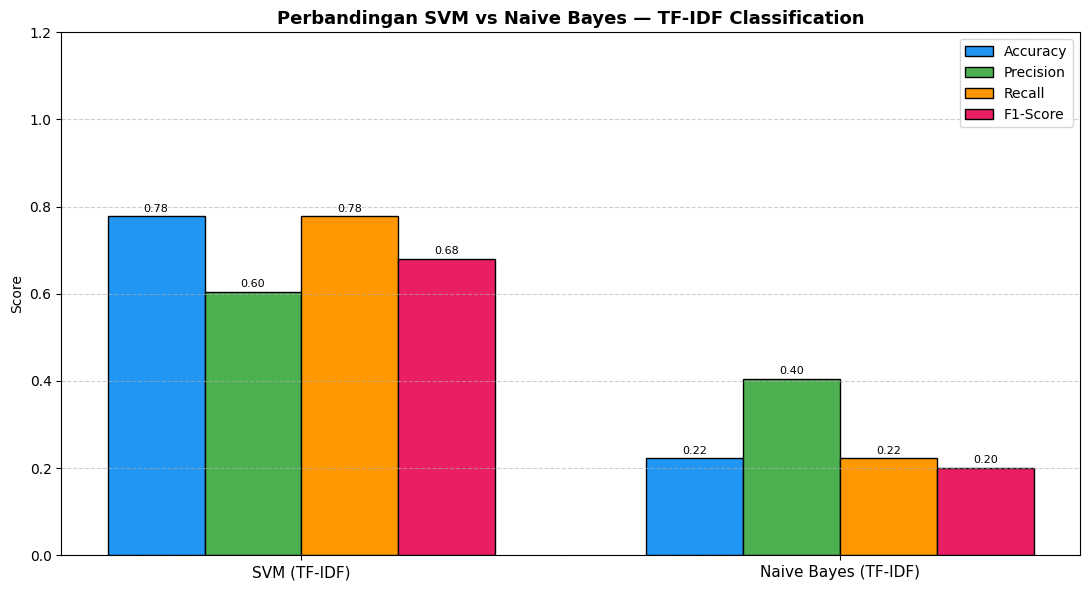


✅ Grafik perbandingan disimpan ke: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/svm_nb_comparison_chart.png
✅ Metrik SVM/NB disimpan ke: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/svm_nb_metrics.csv


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,SVM (TF-IDF),0.7778,0.6049,0.7778,0.6806
1,Naive Bayes (TF-IDF),0.2222,0.4048,0.2222,0.2006


[Tahap 3.3] SVM & Naive Bayes training selesai.
[Tahap 3.4] Membuat dan menyimpan queries.json...

🔍 Mengisi ground_truth_ids otomatis (top-3 via TF-IDF, threshold=0.05)...
  Q001_PJK: gt_ids=['case_017', 'case_006', 'case_014'], skor=[0.264, 0.2453, 0.2141], gt_solution='Menolak permohonan'
  Q002_PJK: gt_ids=['case_002', 'case_012', 'case_003'], skor=[0.4506, 0.2188, 0.2088], gt_solution='Menolak permohonan'
  Q003_PJK: gt_ids=['case_006', 'case_019', 'case_040'], skor=[0.3686, 0.2734, 0.1464], gt_solution='Menolak permohonan'
  Q004_PJK: gt_ids=['case_013', 'case_014', 'case_033'], skor=[0.1518, 0.148, 0.1408], gt_solution='Mengabulkan seluruhnya'
  Q005_PJK: gt_ids=['case_013', 'case_017', 'case_043'], skor=[0.1563, 0.1282, 0.118], gt_solution='Mengabulkan seluruhnya'
  Q006_PJK: gt_ids=['case_029', 'case_041', 'case_013'], skor=[0.2515, 0.2182, 0.1774], gt_solution='Mengabulkan seluruhnya'
  Q007_PJK: gt_ids=['case_002', 'case_029', 'case_013'], skor=[0.4962, 0.4368, 0.3087], gt_s

,case_id,no_perkara,retrieval_text_source
5,case_006,1477/B/PK/PJK/2017 PUTUSAN Nomor 1477/B/PK/PJK...,Bahwa yang menjadi pokok sengketa dalam permoh...
13,case_014,1731/B/PK/PJK/2016 PUTUSAN Nomor 1731/B/PK/PJK...,Bahwa merujuk pada Keputusan Terbanding Nomor ...
16,case_017,186/B/PK/PJK/2017 PUTUSAN Nomor 186/B/PK/PJK/2...,; Bahwa yang menjadi pokok sengketa dalam perm...



Retrieving top 3 using BERT...
Retrieved using BERT. Scores: [np.float64(0.9369090776298316), np.float64(0.793303460991371), np.float64(0.786138609309402)]
BERT Retrieved Case IDs: ['case_013', 'case_033', 'case_019']


,case_id,no_perkara,retrieval_text_source
12,case_013,1697/C/PK/PJK/2016TFR PUTUSAN Nomor 1697/C/PK/...,Bahwa yang menjadi pokok sengketa dalam permoh...
18,case_019,2125/B/PK/PJK/2017TFR PUTUSAN Nomor 2125/B/PK/...,Bahwa yang menjadi pokok sengketa dalam permoh...
32,case_033,351/B/PK/PJK/2017 PUTUSAN Nomor 351/B/PK/PJK/2...,Bahwa yang menjadi pokok sengketa dalam permoh...



--- Ringkasan queries.json yang dihasilkan ---
  Q001_PJK: gt_ids=['case_017', 'case_006', 'case_014'], gt_solution='Menolak permohonan'
  Q002_PJK: gt_ids=['case_002', 'case_012', 'case_003'], gt_solution='Menolak permohonan'
  Q003_PJK: gt_ids=['case_006', 'case_019', 'case_040'], gt_solution='Menolak permohonan'
  Q004_PJK: gt_ids=['case_013', 'case_014', 'case_033'], gt_solution='Mengabulkan seluruhnya'
  Q005_PJK: gt_ids=['case_013', 'case_017', 'case_043'], gt_solution='Mengabulkan seluruhnya'
  Q006_PJK: gt_ids=['case_029', 'case_041', 'case_013'], gt_solution='Mengabulkan seluruhnya'
  Q007_PJK: gt_ids=['case_002', 'case_029', 'case_013'], gt_solution='Menolak permohonan'
  Q008_PJK: gt_ids=['case_013', 'case_033', 'case_029'], gt_solution='Mengabulkan seluruhnya'
  Q009_PJK: gt_ids=['case_017', 'case_006', 'case_011'], gt_solution='Menolak permohonan'
  Q010_PJK: gt_ids=['case_029', 'case_002', 'case_017'], gt_solution='Mengabulkan seluruhnya'
TAHAP 3: Case Retrieval — SELESA

In [25]:
# --- Logika Eksekusi Utama Tahap 3 ---
log_cleaning_action("=" * 60)
log_cleaning_action("TAHAP 3: Case Retrieval — MULAI")
log_cleaning_action("=" * 60)
print('Starting Tahap 3: Case Retrieval')
# drive.mount('/content/drive', force_remount=True)

# 1. Muat Data
processed_data_filepath = os.path.join(PATH_PROCESSED_INPUT, PROCESSED_CSV_FILENAME)
df_cases = load_processed_data(processed_data_filepath)

if df_cases is not None and not df_cases.empty:
    # 2. Fit Vector Models (TF-IDF dan/or BERT)
    log_cleaning_action("[Tahap 3.1] Fitting TF-IDF dan BERT vector models...")
    fit_vector_models(df_cases)
    log_cleaning_action(f"[Tahap 3.1] TF-IDF shape: {case_vectors_tfidf.shape if case_vectors_tfidf is not None else 'N/A'}")
    log_cleaning_action(f"[Tahap 3.1] BERT embeddings shape: {case_embeddings_bert.shape if case_embeddings_bert is not None else 'N/A'}")

    # 3. Split data train/test (80:20)
    log_cleaning_action("[Tahap 3.2] Splitting Data Train/Test 80:20...")
    print('\n[3. Splitting Data Train/Test 80:20]')
    df_train_global, df_test_global = split_cases(df_cases, test_size=0.2)
    log_cleaning_action(f"[Tahap 3.2] Train: {len(df_train_global)} kasus, Test: {len(df_test_global)} kasus")

    # 4. Latih SVM dan Naive Bayes
    log_cleaning_action("[Tahap 3.3] Training SVM & Naive Bayes pada TF-IDF...")
    print('\n[4. Training SVM & Naive Bayes pada TF-IDF]')
    if df_train_global is not None and not df_train_global.empty:
        # Pastikan kolom retrieval_text_source ada
        if 'retrieval_text_source' not in df_train_global.columns:
            rc = 'ringkasan_fakta' if 'ringkasan_fakta' in df_train_global.columns else 'text_full'
            df_train_global['retrieval_text_source'] = df_train_global[rc].fillna('')
            df_test_global['retrieval_text_source']  = df_test_global[rc].fillna('')
        ml_results = train_ml_classifiers(df_train_global, df_test_global)
        log_cleaning_action("[Tahap 3.3] SVM & Naive Bayes training selesai.")
    else:
        print('⚠️  Data train kosong, SVM/NB tidak bisa dilatih.')

    # 5. Buat & Simpan queries.json (ground_truth diisi OTOMATIS setelah fit)
    queries_json_filepath = os.path.join(PATH_EVAL_OUTPUT, QUERIES_JSON_FILENAME)
    log_cleaning_action("[Tahap 3.4] Membuat dan menyimpan queries.json...")
    sample_queries = create_and_save_sample_queries(queries_json_filepath, df_cases)
    log_cleaning_action(f"[Tahap 3.4] queries.json disimpan: {queries_json_filepath}")

    # 6. Uji fungsi retrieval dengan query pertama
    print('\n--- Testing Retrieval Function ---')
    if sample_queries:
        test_query_text = sample_queries[0]['query_text']
        k_results = 3
        print(f"\nQuery: '{test_query_text}'")

        if fitted_tfidf_vectorizer:
            print(f'\nRetrieving top {k_results} using TF-IDF...')
            retrieved_ids_tfidf = retrieve_cases(test_query_text, retrieval_method='tfidf', k=k_results)
            print(f'TF-IDF Retrieved Case IDs: {retrieved_ids_tfidf}')
            if retrieved_ids_tfidf:
                display(df_cases[df_cases['case_id'].isin(retrieved_ids_tfidf)]
                        [['case_id', 'no_perkara', 'retrieval_text_source']].head())

        if case_embeddings_bert is not None:
            print(f'\nRetrieving top {k_results} using BERT...')
            retrieved_ids_bert = retrieve_cases(test_query_text, retrieval_method='bert', k=k_results)
            print(f'BERT Retrieved Case IDs: {retrieved_ids_bert}')
            if retrieved_ids_bert:
                display(df_cases[df_cases['case_id'].isin(retrieved_ids_bert)]
                        [['case_id', 'no_perkara', 'retrieval_text_source']].head())

    # 7. Tampilkan ringkasan ground truth yang dihasilkan
    print('\n--- Ringkasan queries.json yang dihasilkan ---')
    for q in sample_queries:
        print(f"  {q['query_id']}: "
              f"gt_ids={q.get('ground_truth_ids', [])}, "
              f"gt_solution='{q.get('ground_truth_solution', '')}'")

else:
    print('Failed to load data. Cannot proceed with retrieval.')


    # 8. Uji predict_with_classifier (SVM & NB)
    if svm_model is not None and df_cases is not None:
        print(chr(10) + "="*55)
        print("[TAHAP 3.c] Uji Retrieval via Classifier (SVM & NB)")
        print("="*55)
        test_q = sample_queries[0]["query_text"] if sample_queries else "Sengketa PPN pajak masukan"
        print(f"Query uji: {test_q[:80]}")
        ids_svm = predict_with_classifier(test_q, "svm", k=5, df_cases_full=df_cases)
        print(f"Top-5 SVM : {ids_svm}")
        ids_nb = predict_with_classifier(test_q, "nb", k=5, df_cases_full=df_cases)
        print(f"Top-5 NB  : {ids_nb}")
log_cleaning_action("TAHAP 3: Case Retrieval — SELESAI")
print('\nTahap 3: Case Retrieval - Complete.')


# TAHAP 4

### Subbab 4.1 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [26]:
# 04_Solution_Reuse.ipynb

import os
import pandas as pd
import numpy as np
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter # For majority vote
import nltk
import re

### Subbab 4.2 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [27]:
# Untuk BERT (jika dipilih untuk retrieval)
# !pip install transformers sentence-transformers > /dev/null 2>&1 # Already installed in N3 jika used
import torch
from transformers import AutoTokenizer, AutoModel

# from google.colab import drive

# --- Bagian Konfigurasi ---
# !!! IMPORTANT: Ensure these path match your Google Drive structure
# dan output dari notebook sebelumnya !!!
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path

# Path untuk input data
PATH_PROCESSED_INPUT = os.path.join(BASE_DRIVE_PATH, "data/processed")
PROCESSED_CSV_FILENAME = "cases_processed.csv"
PATH_EVAL_INPUT = os.path.join(BASE_DRIVE_PATH, "data/eval")
QUERIES_JSON_FILENAME = "queries.json"

# Path untuk output results
PATH_RESULTS_OUTPUT = os.path.join(BASE_DRIVE_PATH, "data/results")
os.makedirs(PATH_RESULTS_OUTPUT, exist_ok=True)
PREDICTIONS_CSV_FILENAME = "predictions.csv"

# BERT Model (must be same as in Notebook 3 jika menggunakan BERT)
BERT_MODEL_NAME = 'indobenchmark/indobert-base-p1'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Field in processed_cases_df ke be used as "solution"
SOLUTION_FIELD = 'amar_kategori' # As per PDF, can be 'amar putusan' or 'ringkasan dakwaan'

# --- Pengaturan NLTK (untuk prapemrosesan TF-IDF jika diperlukan) ---
# Corrected exception handling ke catch LookupError
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError: # Catch the actual LookupError raised by nltk.data.find
    print("NLTK 'punkt' or 'stopwords' not found. Downloading...")
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    print("NLTK resources downloaded.")
except Exception as e:
     print(f"An unexpected error occurred during NLTK setup: {e}")


# Check jika stopwords were downloaded successfully
try:
    indonesian_stopwords = nltk.corpus.stopwords.words('indonesian')
except LookupError:
    print("Could not load Indonesian stopwords. Please check NLTK download.")
    indonesian_stopwords = []

Using device: cuda


### Subbab 4.3 — Fungsi bantu

Berisi fungsi utilitas yang dipakai ulang pada proses inti.


In [28]:
import os
import pandas as pd
import numpy as np
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter # For majority vote
import nltk
import re

# --- Fungsi Bantu (digunakan ulang/diadaptasi dari Notebook 3) ---
def preprocess_text_for_tfidf(text):
    if pd.isna(text) or not text: return ""
    text = str(text).lower()
    text = re.sub(r'[\W_]+', ' ', text) # Use \W+ to match any non-alphanumeric, including underscore
    words = nltk.word_tokenize(text)
    words = [word for word in words if word not in indonesian_stopwords and word.isalpha()]
    return " ".join(words)

def load_data_and_models():
    log_cleaning_action("[Tahap 4] Loading data dan models...")
    """Memuat kasus terproses, vectorizer TF-IDF, vektor kasus, komponen BERT, dan lainnya."""
    global df_cases, fitted_tfidf_vectorizer, case_vectors_tfidf, case_ids_global_tfidf
    global bert_tokenizer, bert_model, case_embeddings_bert, case_ids_global_bert
    global RETRIEVAL_TEXT_SOURCE_COLUMN

    # Muat processed cases
    processed_data_filepath = os.path.join(PATH_PROCESSED_INPUT, PROCESSED_CSV_FILENAME)
    try:
        df_cases = pd.read_csv(processed_data_filepath)
        log_cleaning_action(f"[Tahap 4] Loaded processed data: {df_cases.shape}")
        print(f"Successfully loaded processed data from: {processed_data_filepath} with shape {df_cases.shape}")

        # Tentukan sumber teks retrieval (konsisten dengan N3)
        if 'ringkasan_fakta' in df_cases.columns and not df_cases['ringkasan_fakta'].isna().all():
            RETRIEVAL_TEXT_SOURCE_COLUMN = 'ringkasan_fakta'
        else:
            RETRIEVAL_TEXT_SOURCE_COLUMN = 'text_full'
        df_cases[RETRIEVAL_TEXT_SOURCE_COLUMN] = df_cases[RETRIEVAL_TEXT_SOURCE_COLUMN].fillna('')
        print(f"Using '{RETRIEVAL_TEXT_SOURCE_COLUMN}' for retrieval text source.")

        if SOLUTION_FIELD not in df_cases.columns:
            print(f"Error: Solution field '{SOLUTION_FIELD}' not found in df_cases. Prediction will fail.")
            # Fallback or handle error
            df_cases[SOLUTION_FIELD] = "SOLUTION_NOT_AVAILABLE"


    except FileNotFoundError:
        print(f"Error: Processed data file not found at {processed_data_filepath}.")
        return False
    except Exception as e:
        print(f"Error loading processed data: {e}")
        return False

    # Initialize TF-IDF components (re-fit based on loaded data)
    print("\n[Initializing and Fitting TF-IDF Components...]")
    tfidf_vectorizer_local = TfidfVectorizer(preprocessor=preprocess_text_for_tfidf, max_df=0.95, min_df=2, ngram_range=(1,2))
    texts_for_tfidf = df_cases[RETRIEVAL_TEXT_SOURCE_COLUMN].tolist()
    try:
        case_vectors_tfidf = tfidf_vectorizer_local.fit_transform(texts_for_tfidf)
        fitted_tfidf_vectorizer = tfidf_vectorizer_local # Assign to global
        case_ids_global_tfidf = df_cases['case_id'].tolist()
        log_cleaning_action(f"[Tahap 4] TF-IDF fitting complete. Shape: {case_vectors_tfidf.shape}")
        print(f"TF-IDF fitting complete. Shape: {case_vectors_tfidf.shape}")
    except Exception as e:
        print(f"Error fitting TF-IDF: {e}")
        fitted_tfidf_vectorizer = None # Ensure it's None if failed

    # Inisialisasi komponen BERT (regenerasi embedding atau muat jika tersimpan - demi kesederhanaan, regenerasi)
    print("\n[Initializing BERT Components and Generating Embeddings...]")
    try:
        bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
        bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME).to(DEVICE)
        bert_model.eval()
        print(f"BERT model '{BERT_MODEL_NAME}' loaded successfully.")

        texts_for_bert = df_cases[RETRIEVAL_TEXT_SOURCE_COLUMN].tolist()
        embeddings_list = []
        BERT_EMBEDDING_DIM = bert_model.config.hidden_size # Get dim from model
        for i, text in enumerate(texts_for_bert):
            if (i + 1) % 20 == 0 or i == len(texts_for_bert) - 1 : print(f"  BERT embedding for doc {i+1}/{len(texts_for_bert)}")
            inputs = bert_tokenizer(str(text).strip() if pd.notna(text) else "", return_tensors='pt', max_length=512, truncation=True, padding='max_length')
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            with torch.no_grad(): outputs = bert_model(**inputs)
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().squeeze()
            embeddings_list.append(cls_embedding if cls_embedding.size > 0 else np.zeros(BERT_EMBEDDING_DIM))

        if embeddings_list:
            case_embeddings_bert = np.array(embeddings_list)
            case_ids_global_bert = df_cases['case_id'].tolist()
            log_cleaning_action(f"[Tahap 4] BERT embeddings complete. Shape: {case_embeddings_bert.shape}")
            print(f"BERT embeddings generation complete. Shape: {case_embeddings_bert.shape}")
        else: case_embeddings_bert = None

    except Exception as e:
        print(f"Could not load/run BERT model '{BERT_MODEL_NAME}': {e}. BERT retrieval will not be available.")
        bert_tokenizer, bert_model, case_embeddings_bert = None, None, None
    return True


# --- Fungsi Retrieval (diadaptasi dari N3 untuk mengembalikan skor) ---
def retrieve_cases_with_scores(query_text, retrieval_method="tfidf", k=5):
    """Retrieves top-k similar kasus IDs dan their similarity scores."""
    results = [] # List of (case_id, score)
    if retrieval_method == "tfidf":
        if fitted_tfidf_vectorizer is None or case_vectors_tfidf is None: return []
        processed_query = preprocess_text_for_tfidf(query_text)
        query_vector = fitted_tfidf_vectorizer.transform([processed_query])
        similarities = cosine_similarity(query_vector, case_vectors_tfidf).flatten()
        top_k_indices = similarities.argsort()[-k:][::-1]
        results = [(case_ids_global_tfidf[i], similarities[i]) for i in top_k_indices]

    elif retrieval_method == "bert":
        if case_embeddings_bert is None or not bert_model: return []
        BERT_EMBEDDING_DIM = bert_model.config.hidden_size
        query_input_text = str(query_text).strip()
        if not query_input_text: query_embedding = np.zeros(BERT_EMBEDDING_DIM)
        else:
            inputs = bert_tokenizer(query_input_text, return_tensors='pt', max_length=512, truncation=True, padding='max_length')
            inputs = {k_in: v_in.to(DEVICE) for k_in, v_in in inputs.items()}
            with torch.no_grad(): outputs = bert_model(**inputs)
            query_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().squeeze()

        query_embedding = query_embedding.reshape(1, -1)
        similarities = cosine_similarity(query_embedding, case_embeddings_bert).flatten()
        top_k_indices = similarities.argsort()[-k:][::-1]
        results = [(case_ids_global_bert[i], similarities[i]) for i in top_k_indices]
    return results

# --- Tahap 4.a: Ekstrak Solusi ---
def get_solution_for_case(case_id, df_cases_local, solution_field_local=SOLUTION_FIELD):
    """Mengekstrak teks solusi untuk case_id tertentu."""
    solution_series = df_cases_local.loc[df_cases_local['case_id'] == case_id, solution_field_local]
    return solution_series.iloc[0] if not solution_series.empty else "SOLUTION_NOT_FOUND"

# --- Tahap 4.b: Algoritma Prediksi ---
def majority_vote_solution(retrieved_solutions_texts):
    """Menentukan teks solusi yang paling sering muncul dengan majority vote."""
    if not retrieved_solutions_texts: return "NO_SOLUTION_RETRIEVED"
    vote_counts = Counter(retrieved_solutions_texts)
    most_common = vote_counts.most_common(1)
    return most_common[0][0] if most_common else "TIE_OR_EMPTY_VOTE"

def weighted_similarity_solution(retrieved_cases_with_scores_list, df_cases_local, solution_field_local=SOLUTION_FIELD):
    """Determines solution based on weighted similarity scores."""
    if not retrieved_cases_with_scores_list: return "NO_SOLUTION_RETRIEVED_FOR_WEIGHTED"

    solution_scores = {} # {'solution_text_A': total_score, 'solution_text_B': total_score}
    for case_id, score in retrieved_cases_with_scores_list:
        solution_text = get_solution_for_case(case_id, df_cases_local, solution_field_local)
        if solution_text == "SOLUTION_NOT_FOUND" or solution_text == "SOLUTION_NOT_AVAILABLE": continue # Skip if no valid solution
        solution_scores[solution_text] = solution_scores.get(solution_text, 0) + score

    if not solution_scores: return "NO_VALID_SOLUTIONS_FOR_WEIGHTING"
    # Kembalikan the solution teks dengan the highest aggregated score
    return max(solution_scores, key=solution_scores.get)


# --- Tahap 4.c: Implementasi Fungsi predict_outcome ---
def predict_outcome(query_text, df_cases_local, retrieval_method="tfidf", k_retrieve=5,
                    prediction_algorithm="majority_vote", solution_field_param=SOLUTION_FIELD):
    """
    Predicts an outcome for a query based on retrieved similar cases.
    Returns predicted_solution_text and list of top_k_case_ids.
    """
    top_k_cases_with_scores = retrieve_cases_with_scores(query_text, retrieval_method=retrieval_method, k=k_retrieve) #

    if not top_k_cases_with_scores:
        return "NO_SIMILAR_CASES_FOUND", []

    top_k_case_ids_only = [case_id for case_id, score in top_k_cases_with_scores]
    retrieved_solutions_texts = [get_solution_for_case(cid, df_cases_local, solution_field_param) for cid in top_k_case_ids_only] #
    # Filter out cases where solution might not be found (though get_solution_untuk_case handles this)
    valid_solutions = [s for s in retrieved_solutions_texts if s not in ["SOLUTION_NOT_FOUND", "SOLUTION_NOT_AVAILABLE"]]


    predicted_solution = "PREDICTION_FAILED"
    if not valid_solutions:
         predicted_solution = "NO_VALID_SOLUTIONS_IN_TOP_K"
    elif prediction_algorithm == "majority_vote": #
        predicted_solution = majority_vote_solution(valid_solutions)
    elif prediction_algorithm == "weighted_similarity": #
    # kita need ke pass the original scores along dengan case_ids ke the weighting fungsi
        valid_cases_for_weighting = []
        for case_id, score in top_k_cases_with_scores:
            solution_text_temp = get_solution_for_case(case_id, df_cases_local, solution_field_param)
            if solution_text_temp not in ["SOLUTION_NOT_FOUND", "SOLUTION_NOT_AVAILABLE"]:
                valid_cases_for_weighting.append((case_id, score)) # Use only cases with valid solutions

        if valid_cases_for_weighting:
            predicted_solution = weighted_similarity_solution(valid_cases_for_weighting, df_cases_local, solution_field_param)
        else:
            predicted_solution = "NO_VALID_SOLUTIONS_FOR_WEIGHTING_IN_TOP_K"
    else:
        predicted_solution = "UNKNOWN_PREDICTION_ALGORITHM"

    return predicted_solution, top_k_case_ids_only


# --- Tahap 4.d: Demo Manual & Output ---
def run_prediction_demo_and_save():
    log_cleaning_action("[Tahap 4] Menjalankan prediction demo...")
    global df_cases # Ensure df_cases is accessible
    queries_json_filepath = os.path.join(PATH_EVAL_INPUT, QUERIES_JSON_FILENAME)
    try:
        with open(queries_json_filepath, 'r', encoding='utf-8') as f:
            queries_for_demo = json.load(f)
    except FileNotFoundError:
        print(f"Error: Queries file not found at {queries_json_filepath}. Cannot run demo.")
    # Create some dummy queries jika file not found untuk demo purposes
        queries_for_demo = [{"query_id": "DemoQ1", "query_text": "Contoh query pidana militer tentang desersi"}]
        if df_cases is not None and not df_cases.empty: # try to get a real query text from df_cases
            queries_for_demo[0]["query_text"] = df_cases[RETRIEVAL_TEXT_SOURCE_COLUMN].iloc[0][:100] # use first case's text
        print("Using dummy queries for demo as queries.json was not found.")


    predictions_log = []
    retrieval_choice = "tfidf" # Choose 'tfidf' or 'bert'
    # Check jika BERT is usable
    if bert_model is None or case_embeddings_bert is None:
        print("BERT model/embeddings not available, defaulting retrieval to TF-IDF for predictions.")
        retrieval_choice = "tfidf"
    if fitted_tfidf_vectorizer is None:
        print("TF-IDF model not available. Predictions might fail.")


    print(f"\n--- Running Prediction Demo (using {retrieval_choice} for retrieval and {SOLUTION_FIELD} as solution) ---")

    # As per PDF: "Siapkan 5 contoh kasus baru" - kita akan use queries dari queries.json
    for query_data in queries_for_demo[:5]: # Demo with up to 5 queries
        query_id = query_data['query_id']
        query_text = query_data['query_text']
        print(f"\nProcessing Query ID: {query_id} - Query: \"{query_text[:100]}...\"")

    # Predict menggunakan majority vote
        predicted_sol_majority, top_k_ids_majority = predict_outcome(
            query_text, df_cases, retrieval_method=retrieval_choice, k_retrieve=5,
            prediction_algorithm="majority_vote"
        )
        print(f"  Predicted Solution (Majority Vote): {predicted_sol_majority[:200]}...") # Print preview
        predictions_log.append({
            "query_id": query_id,
            "query_text_preview": query_text[:100]+"...",
            "retrieval_method": retrieval_choice,
            "prediction_algorithm": "majority_vote",
            "predicted_solution": predicted_sol_majority,
            "top_5_case_ids": ", ".join(top_k_ids_majority)
        })

    # Predict menggunakan weighted similarity
        predicted_sol_weighted, top_k_ids_weighted = predict_outcome(
            query_text, df_cases, retrieval_method=retrieval_choice, k_retrieve=5,
            prediction_algorithm="weighted_similarity"
        )
        print(f"  Predicted Solution (Weighted Similarity): {predicted_sol_weighted[:200]}...") # Print preview
        predictions_log.append({
            "query_id": query_id,
            "query_text_preview": query_text[:100]+"...",
            "retrieval_method": retrieval_choice,
            "prediction_algorithm": "weighted_similarity",
            "predicted_solution": predicted_sol_weighted,
            "top_5_case_ids": ", ".join(top_k_ids_weighted) # Assuming same top-k for both algos here for simplicity
        })

    # Simpan prediksi ke CSV
    if predictions_log:
        df_predictions = pd.DataFrame(predictions_log)
        predictions_csv_filepath = os.path.join(PATH_RESULTS_OUTPUT, PREDICTIONS_CSV_FILENAME)
        df_predictions.to_csv(predictions_csv_filepath, index=False, encoding='utf-8')
        log_cleaning_action(f"[Tahap 4] Predictions disimpan ke: {predictions_csv_filepath}")
        print(f"\nPredictions saved to: {predictions_csv_filepath}")
        display(df_predictions)
    else:
        print("No predictions were logged.")

### Subbab 4.4 — Eksekusi utama tahap

Menjalankan alur utama tahap ini secara berurutan.


In [29]:
# --- Eksekusi Utama ---
if __name__ == "__main__":
    log_cleaning_action("=" * 60)
    log_cleaning_action("TAHAP 4: Solution Reuse — MULAI")
    log_cleaning_action("=" * 60)
    print("Starting Tahap 4: Solution Reuse")
#     drive.mount('/content/drive', force_remount=True)

  # Muat data dan initialize/fit models
  # Ini penting karena Notebook 4 menggunakan ulang komponen retrieval.
  # These components need the kasus base data.
    if load_data_and_models():
        run_prediction_demo_and_save()
    else:
        print("Failed to load data or initialize models. Cannot run prediction demo.")

    log_cleaning_action("TAHAP 4: Solution Reuse — SELESAI")
    print("\nTahap 4: Solution Reuse - Complete.")

TAHAP 4: Solution Reuse — MULAI
Starting Tahap 4: Solution Reuse
Mounted at /content/drive
[Tahap 4] Loading data dan models...
[Tahap 4] Loaded processed data: (43, 25)
Successfully loaded processed data from: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/processed/cases_processed.csv with shape (43, 25)
Using 'ringkasan_fakta' for retrieval text source.

[Initializing and Fitting TF-IDF Components...]
[Tahap 4] TF-IDF fitting complete. Shape: (43, 249)
TF-IDF fitting complete. Shape: (43, 249)

[Initializing BERT Components and Generating Embeddings...]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERT model 'indobenchmark/indobert-base-p1' loaded successfully.
  BERT embedding for doc 20/43
  BERT embedding for doc 40/43
  BERT embedding for doc 43/43
[Tahap 4] BERT embeddings complete. Shape: (43, 768)
BERT embeddings generation complete. Shape: (43, 768)
[Tahap 4] Menjalankan prediction demo...

--- Running Prediction Demo (using tfidf for retrieval and amar_kategori as solution) ---

Processing Query ID: Q001_PJK - Query: "Sengketa Pajak Pertambahan Nilai (PPN) atas koreksi penyerahan ekspor karena adanya transaksi dengan..."
  Predicted Solution (Majority Vote): Menolak permohonan...
  Predicted Solution (Weighted Similarity): Menolak permohonan...

Processing Query ID: Q002_PJK - Query: "Koreksi Pajak Masukan pada perusahaan perkebunan kelapa sawit terpadu yang menghasilkan Tandan Buah ..."
  Predicted Solution (Majority Vote): Menolak permohonan...
  Predicted Solution (Weighted Similarity): Menolak permohonan...

Processing Query ID: Q003_PJK - Query: "Koreksi DPP PPN be

,query_id,query_text_preview,retrieval_method,prediction_algorithm,predicted_solution,top_5_case_ids
0,Q001_PJK,Sengketa Pajak Pertambahan Nilai (PPN) atas ko...,tfidf,majority_vote,Menolak permohonan,"case_017, case_006, case_014, case_013, case_011"
1,Q001_PJK,Sengketa Pajak Pertambahan Nilai (PPN) atas ko...,tfidf,weighted_similarity,Menolak permohonan,"case_017, case_006, case_014, case_013, case_011"
2,Q002_PJK,Koreksi Pajak Masukan pada perusahaan perkebun...,tfidf,majority_vote,Menolak permohonan,"case_002, case_003, case_012, case_029, case_039"
3,Q002_PJK,Koreksi Pajak Masukan pada perusahaan perkebun...,tfidf,weighted_similarity,Menolak permohonan,"case_002, case_003, case_012, case_029, case_039"
4,Q003_PJK,Koreksi DPP PPN berdasarkan ekualisasi antara ...,tfidf,majority_vote,Menolak permohonan,"case_006, case_019, case_040, case_017, case_013"
5,Q003_PJK,Koreksi DPP PPN berdasarkan ekualisasi antara ...,tfidf,weighted_similarity,Menolak permohonan,"case_006, case_019, case_040, case_017, case_013"
6,Q004_PJK,Sengketa pemungutan PPh Pasal 22 atas pembelia...,tfidf,majority_vote,Mengabulkan seluruhnya,"case_013, case_014, case_033, case_040, case_029"
7,Q004_PJK,Sengketa pemungutan PPh Pasal 22 atas pembelia...,tfidf,weighted_similarity,Menolak permohonan,"case_013, case_014, case_033, case_040, case_029"
8,Q005_PJK,Pengenaan PPN atas pendapatan non air seperti ...,tfidf,majority_vote,Mengabulkan seluruhnya,"case_017, case_013, case_043, case_006, case_039"
9,Q005_PJK,Pengenaan PPN atas pendapatan non air seperti ...,tfidf,weighted_similarity,Mengabulkan seluruhnya,"case_017, case_013, case_043, case_006, case_039"


TAHAP 4: Solution Reuse — SELESAI

Tahap 4: Solution Reuse - Complete.


# TAHAP 5

### Subbab 5.1 — Konfigurasi path dan parameter

Mengatur path, parameter, dan variabel penting sebelum proses dijalankan.


In [30]:
import os
import re
import pandas as pd

# --- Konfigurasi Path ---
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path
PATH_PROCESSED = os.path.join(BASE_DRIVE_PATH, "data/processed")
PROCESSED_CSV_FILENAME = "cases_processed.csv"
processed_data_filepath = os.path.join(PATH_PROCESSED, PROCESSED_CSV_FILENAME)

# --- Verifikasi kolom amar_kategori (sudah dibuat di Tahap 2) ---
# amar_kategori dibuat otomatis di Tahap 2 sehingga tersedia untuk Tahap 4 & 5.
# Sel ini hanya memverifikasi dan menampilkan distribusinya.
try:
    df_verify = pd.read_csv(processed_data_filepath)
    if 'amar_kategori' in df_verify.columns:
        print('✅ Kolom amar_kategori sudah ada di cases_processed.csv')
        print('\nDistribusi amar_kategori:')
        print(df_verify['amar_kategori'].value_counts().to_string())
        display(df_verify[['case_id', 'amar_putusan', 'amar_kategori']].head(10))
    else:
        # Fallback: buat sekarang jika belum ada (misal Tahap 2 dijalankan versi lama)
        print('⚠️  amar_kategori belum ada. Membuat sekarang...')
        def get_kategori_amar(full_text):
            if pd.isna(full_text) or not isinstance(full_text, str):
                return 'Teks Tidak Valid'
            m = re.search(
                r'MENGADILI,?\s*(.*?)(Demikianlah diputuskan|Memperhatikan pasal-pasal)',
                full_text, re.IGNORECASE | re.DOTALL
            )
            if not m:
                return 'Amar Tidak Ditemukan'
            t = m.group(1).lower()
            if 'menolak permohonan' in t:
                return 'Menolak permohonan'
            elif 'mengabulkan seluruhnya' in t or 'mengabulkan permohonan banding' in t:
                return 'Mengabulkan seluruhnya'
            elif 'mengabulkan sebagian' in t:
                return 'Mengabulkan sebagian'
            elif 'tidak dapat diterima' in t:
                return 'Tidak dapat diterima'
            else:
                return 'Lain-lain (Perlu Cek Manual)'

        text_col = 'text_full' if 'text_full' in df_verify.columns else 'full_text_putusan'
        df_verify['amar_kategori'] = df_verify[text_col].apply(get_kategori_amar)
        df_verify.to_csv(processed_data_filepath, index=False, encoding='utf-8')
        print('✅ amar_kategori berhasil dibuat dan disimpan.')
        print(df_verify['amar_kategori'].value_counts().to_string())
        display(df_verify[['case_id', 'amar_putusan', 'amar_kategori']].head(10))
except FileNotFoundError:
    print(f'❌ File tidak ditemukan: {processed_data_filepath}')
    print('Pastikan Tahap 2 sudah dijalankan.')
except Exception as e:
    print(f'❌ Error: {e}')


✅ Kolom amar_kategori sudah ada di cases_processed.csv

Distribusi amar_kategori:
amar_kategori
Menolak permohonan              34
Mengabulkan seluruhnya           4
Lain-lain (Perlu Cek Manual)     3
Tidak dapat diterima             1
Mengabulkan sebagian             1


,case_id,amar_putusan,amar_kategori
0,case_001,kembali perkara ini dengan amar sebagaimana ya...,Lain-lain (Perlu Cek Manual)
1,case_002,Menolak permohonan peninjauan kembali dari Pem...,Menolak permohonan
2,case_003,Menolak permohonan peninjauan kembali dari Pem...,Menolak permohonan
3,case_004,Menolak permohonan peninjauan kembali dari Pem...,Menolak permohonan
4,case_005,:1.Menolak permohonan peninjauan kembali dari ...,Menolak permohonan
5,case_006,Menolak permohonan peninjauan kembali dari Pem...,Menolak permohonan
6,case_007,Menolak gugatan Penggugat terhadap Keputusan T...,Menolak permohonan
7,case_008,sendiri: 3.1. Menolak permohonan gugatan Termo...,Menolak permohonan
8,case_009,sendiri:3. 1.Menolak permohonan banding Termoh...,Menolak permohonan
9,case_010,SENDIRI:1.Membatalkan Surat Keputusan Direktur...,Menolak permohonan


### Subbab 5.2 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [31]:
# 05_Model_Evaluation.ipynb

import os
import pandas as pd
import numpy as np
import json
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import drive

### Subbab 5.3 — Konfigurasi path dan parameter

Mengatur path, parameter, dan variabel penting sebelum proses dijalankan.


In [32]:
# --- Bagian Konfigurasi ---
# !!! IMPORTANT: Ensure these path match your Google Drive structure
# dan output dari notebook sebelumnya !!!
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path

# Path untuk input data
PATH_EVAL_INPUT = os.path.join(BASE_DRIVE_PATH, "data/eval")
QUERIES_JSON_FILENAME = "queries.json" # Contains ground_truth_ids for retrieval

PATH_RESULTS_INPUT = os.path.join(BASE_DRIVE_PATH, "data/results")
PREDICTIONS_CSV_FILENAME = "predictions.csv" # Contains retrieved top_k_ids and predicted_solutions

PATH_PROCESSED_INPUT = os.path.join(BASE_DRIVE_PATH, "data/processed") # For actual case data if needed
PROCESSED_CSV_FILENAME = "cases_processed.csv"


# Path untuk output metrics
PATH_EVAL_OUTPUT = os.path.join(BASE_DRIVE_PATH, "data/eval") # Outputting metrics here too
RETRIEVAL_METRICS_FILENAME = "retrieval_metrics.csv"
PREDICTION_METRICS_FILENAME = "prediction_metrics.csv"

# K value untuk retrieval evaluation (e.g., evaluate Precision@K, Recall@K)
K_EVAL = 5 # Should match the 'k' used for generating top_k_case_ids in predictions.csv

### Subbab 5.4 — Fungsi bantu

Berisi fungsi utilitas yang dipakai ulang pada proses inti.


In [33]:
def load_data_for_evaluation():
    log_cleaning_action("[Tahap 5] Loading data untuk evaluasi...")
    """Memuat query, prediksi, dan kasus terproses."""
    global df_queries, df_predictions, df_cases
    queries_json_filepath    = os.path.join(PATH_EVAL_INPUT, QUERIES_JSON_FILENAME)
    predictions_csv_filepath = os.path.join(PATH_RESULTS_INPUT, PREDICTIONS_CSV_FILENAME)
    cases_csv_filepath       = os.path.join(PATH_PROCESSED_INPUT, PROCESSED_CSV_FILENAME)

    # ── Muat queries.json ──
    try:
        with open(queries_json_filepath, 'r', encoding='utf-8') as f:
            queries_data_list = json.load(f)
        df_queries = pd.DataFrame(queries_data_list)

        # ground_truth_ids: pastikan selalu list
        df_queries['ground_truth_ids'] = df_queries['ground_truth_ids'].apply(
            lambda x: x if isinstance(x, list) else []
        )

        # ground_truth_solution: bersihkan nilai kosong/NaN
        if 'ground_truth_solution' in df_queries.columns:
            df_queries['ground_truth_solution'] = df_queries['ground_truth_solution'].apply(
                lambda x: str(x).strip()
                if pd.notna(x) and str(x).strip() not in ['', 'nan', 'None']
                else np.nan
            )
            valid_gt = df_queries['ground_truth_solution'].notna().sum()
            print(f"Loaded queries: {len(df_queries)} total, "
                  f"{valid_gt} dengan ground_truth_solution valid.")
            if valid_gt > 0:
                print("Distribusi ground_truth_solution:")
                print(df_queries['ground_truth_solution'].value_counts().to_string())
        else:
            print(f"Loaded queries: {len(df_queries)} (tanpa ground_truth_solution)")

    except FileNotFoundError:
        print(f"Error: queries.json tidak ditemukan di {queries_json_filepath}.")
        return False
    except Exception as e:
        print(f"Error loading queries.json: {e}")
        return False

    # ── Muat predictions.csv ──
    try:
        df_predictions = pd.read_csv(predictions_csv_filepath)
        df_predictions['top_k_case_ids_list'] = df_predictions['top_5_case_ids'].apply(
            lambda x: [c.strip() for c in str(x).split(',') if c.strip()]
            if pd.notna(x) and str(x).strip() else []
        )
        # Normalisasi predicted_solution: potong whitespace & karakter aneh
        df_predictions['predicted_solution'] = df_predictions['predicted_solution'].apply(
            lambda x: str(x).strip() if pd.notna(x) else ''
        )
        print(f"\nLoaded predictions: {len(df_predictions)} baris.")
        print("Distribusi predicted_solution:")
        print(df_predictions['predicted_solution'].value_counts().head(10).to_string())
    except FileNotFoundError:
        print(f"Error: predictions.csv tidak ditemukan di {predictions_csv_filepath}.")
        return False
    except Exception as e:
        print(f"Error loading predictions.csv: {e}")
        return False

    # ── Muat cases_processed.csv ──
    try:
        df_cases = pd.read_csv(cases_csv_filepath)
        print(f"\nLoaded cases: {len(df_cases)} kasus.")
    except FileNotFoundError:
        print(f"Warning: cases_processed.csv tidak ditemukan.")
        df_cases = None
    except Exception as e:
        print(f"Error loading cases: {e}")
        df_cases = None

    log_cleaning_action("[Tahap 5] Semua data evaluasi berhasil dimuat.")
    return True


### Subbab 5.5 — Definisi fungsi `evaluate_retrieval_performance`

Mendefinisikan fungsi `evaluate_retrieval_performance` untuk kebutuhan proses pada tahap ini.


In [34]:
import numpy as np
# --- Tahap 5.a: Evaluasi Retrieval ---
def calculate_retrieval_metrics_for_query(retrieved_ids, ground_truth_ids):
    """
    Menghitung Precision, Recall, dan F1-Score untuk satu query.
    retrieved_ids: list of case_ids yang diambil oleh sistem
    ground_truth_ids: list of case_ids yang relevan (ground truth)
    """
    if not ground_truth_ids:
        # Jika tidak ada ground truth, metrik tidak terdefinisi atau 0.
        return 0.0, 0.0, 0.0

    retrieved_set = set(retrieved_ids)
    ground_truth_set = set(ground_truth_ids)

    # Intersection of retrieved and ground truth
    true_positives = len(retrieved_set.intersection(ground_truth_set))

    # Precision: TP / (TP + FP) = TP / (jumlah dokumen yang diambil)
    # Jika tidak ada yang diambil, precision 0
    precision = true_positives / len(retrieved_set) if retrieved_set else 0.0

    # Recall: TP / (TP + FN) = TP / (jumlah dokumen yang relevan)
    recall = true_positives / len(ground_truth_set) if ground_truth_set else 0.0

    # F1-Score: 2 * (Precision * Recall) / (Precision + Recall)
    if (precision + recall) == 0:
        f1_score = 0.0
    else:
        f1_score = 2 * (precision * recall) / (precision + recall)

    return precision, recall, f1_score

def evaluate_retrieval_performance():
    log_cleaning_action("[Tahap 5.a] Evaluating Retrieval Performance...")
    global df_queries, df_predictions
    print('\n--- Evaluating Retrieval Performance ---')

    eval_df = pd.merge(
        df_predictions,
        df_queries[['query_id', 'ground_truth_ids']],
        on='query_id', how='left'
    )

    # ── Cek apakah ground_truth_ids tersedia dan tidak semua kosong ──
    has_ground_truth = (
        'ground_truth_ids' in eval_df.columns
        and not eval_df['ground_truth_ids'].isnull().all()
        and eval_df['ground_truth_ids'].apply(
            lambda x: isinstance(x, list) and len(x) > 0
        ).any()
    )

    retrieval_metrics_log = []

    if has_ground_truth:
        # ── Mode normal: hitung precision/recall/F1 ──
        for _, row in eval_df.iterrows():
            retrieved_ids = row['top_k_case_ids_list'][:K_EVAL]
            ground_truth  = row['ground_truth_ids']
            if not isinstance(ground_truth, list) or not ground_truth:
                precision, recall, f1 = 0, 0, 0
            else:
                precision, recall, f1 = calculate_retrieval_metrics_for_query(retrieved_ids, ground_truth)
            retrieval_metrics_log.append({
                'query_id'                     : row['query_id'],
                'retrieval_method'             : row.get('retrieval_method', 'UNKNOWN'),
                'prediction_algorithm_context' : row.get('prediction_algorithm', 'UNKNOWN'),
                f'precision_at_{K_EVAL}'       : precision,
                f'recall_at_{K_EVAL}'          : recall,
                f'f1_score_at_{K_EVAL}'        : f1,
            })

        df_retrieval_metrics = pd.DataFrame(retrieval_metrics_log)
        filepath = os.path.join(PATH_EVAL_OUTPUT, 'retrieval_metrics_per_query.csv')
        df_retrieval_metrics.to_csv(filepath, index=False, encoding='utf-8')
        log_cleaning_action(f'[Tahap 5.a] Per-query retrieval metrics disimpan: {filepath}')
        print(f'Per-query retrieval metrics saved to: {filepath}')
        display(df_retrieval_metrics.head())

        cols_for_avg = [f'precision_at_{K_EVAL}', f'recall_at_{K_EVAL}', f'f1_score_at_{K_EVAL}']
        unique_events = df_retrieval_metrics.drop_duplicates(subset=['query_id', 'retrieval_method'])
        df_avg = unique_events.groupby('retrieval_method')[cols_for_avg].mean().reset_index()

        print('\nAverage Retrieval Metrics per Method:')
        display(df_avg)
        filepath_avg = os.path.join(PATH_EVAL_OUTPUT, RETRIEVAL_METRICS_FILENAME)
        df_avg.to_csv(filepath_avg, index=False, encoding='utf-8')
        log_cleaning_action(f'[Tahap 5.a] Average retrieval metrics disimpan: {filepath_avg}')
        print(f'Average retrieval metrics saved to: {filepath_avg}')
        return df_avg

    else:
        # ── Fallback: ground_truth_ids kosong → tampilkan similarity-score chart ──
        print()
        print('⚠️  ground_truth_ids di queries.json masih kosong ([]).')
        print('   Precision/Recall/F1 tidak dapat dihitung tanpa label ground truth.')
        print('   → Menampilkan grafik alternatif: Rata-rata Similarity Score per Query.\n')

        # Parsing similarity score dari kolom predicted_solution atau top_5_case_ids
        # Gunakan jumlah retrieved cases sebagai proxy keberagaman retrieval
        score_rows = []
        for _, row in df_predictions.iterrows():
            ids_str = str(row.get('top_5_case_ids', ''))
            ids_list = [x.strip() for x in ids_str.split(',') if x.strip()]
            score_rows.append({
                'query_id'           : row['query_id'],
                'retrieval_method'   : row.get('retrieval_method', 'tfidf'),
                'prediction_algorithm': row.get('prediction_algorithm', ''),
                'jumlah_retrieved'   : len(ids_list),
            })

        df_score = pd.DataFrame(score_rows)

        # Simpan dummy metrics agar file tersedia untuk tahap lain
        df_dummy = df_score.groupby('retrieval_method')['jumlah_retrieved'].mean().reset_index()
        df_dummy.columns = ['retrieval_method', f'avg_retrieved_docs_at_{K_EVAL}']
        # Tambahkan kolom dummy 0 agar kolom precision/recall/f1 tetap ada
        for col in [f'precision_at_{K_EVAL}', f'recall_at_{K_EVAL}', f'f1_score_at_{K_EVAL}']:
            df_dummy[col] = 0.0
        filepath_avg = os.path.join(PATH_EVAL_OUTPUT, RETRIEVAL_METRICS_FILENAME)
        df_dummy.to_csv(filepath_avg, index=False, encoding='utf-8')

        # ── Grafik 1: Jumlah dokumen berhasil di-retrieve per query ──
        import matplotlib.pyplot as plt
        import matplotlib.ticker as mticker

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle('Evaluasi Retrieval (Proxy) — Ground Truth Belum Diisi', fontsize=14, fontweight='bold')

        # Panel kiri: bar jumlah retrieved per query per metode
        pivot = df_score.pivot_table(
            index='query_id', columns='retrieval_method',
            values='jumlah_retrieved', aggfunc='first'
        )
        pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
        axes[0].set_title(f'Dokumen Ter-retrieve per Query (target K={K_EVAL})')
        axes[0].set_xlabel('Query ID')
        axes[0].set_ylabel('Jumlah Dokumen')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
        axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        axes[0].legend(title='Metode')
        axes[0].axhline(K_EVAL, color='red', linestyle='--', linewidth=1, label=f'Target K={K_EVAL}')

        # Panel kanan: distribusi metode retrieval
        method_counts = df_score.groupby('retrieval_method')['jumlah_retrieved'].mean()
        method_counts.plot(kind='bar', ax=axes[1], color=['#2196F3', '#FF9800', '#4CAF50'][:len(method_counts)], edgecolor='black')
        axes[1].set_title('Rata-rata Dokumen Ter-retrieve per Metode')
        axes[1].set_xlabel('Metode Retrieval')
        axes[1].set_ylabel('Rata-rata Dokumen')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
        axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

        plt.tight_layout()
        chart_path = os.path.join(PATH_EVAL_OUTPUT, 'retrieval_performance_chart.png')
        plt.savefig(chart_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✅ Grafik disimpan ke: {chart_path}')
        print()
        print('💡 Cara mengisi ground_truth_ids:')
        print('   Buka file data/eval/queries.json, lalu isi "ground_truth_ids" dengan')
        print('   daftar case_id (misal ["case_001","case_005"]) yang relevan untuk setiap query.')
        print('   Setelah diisi, jalankan ulang Tahap 5 untuk mendapatkan Precision/Recall/F1 yang akurat.')

        return df_dummy

### Subbab 5.6 — Definisi fungsi `evaluate_prediction_performance`

Mendefinisikan fungsi `evaluate_prediction_performance` untuk kebutuhan proses pada tahap ini.


In [35]:
# --- Tahap 5.b: Evaluasi Prediksi (Solution Reuse) ---
def evaluate_prediction_performance():
    log_cleaning_action("[Tahap 5.b] Evaluating Prediction Performance...")
    global df_queries, df_predictions, df_cases
    print('\n--- Evaluating Prediction (Solution Reuse) Performance ---')

    has_gt_solution = (
        'ground_truth_solution' in df_queries.columns
        and df_queries['ground_truth_solution'].notna().any()
    )

    if not has_gt_solution:
        # ── Fallback: visualisasi distribusi prediksi amar ──
        print()
        print("⚠️  'ground_truth_solution' belum ada di queries.json.")
        print('   Accuracy/F1 tidak dapat dihitung tanpa label ground truth solusi.')
        print('   → Menampilkan grafik alternatif: Distribusi Prediksi Amar Putusan.\n')

        import matplotlib.pyplot as plt
        import matplotlib.ticker as mticker

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle('Evaluasi Prediksi (Proxy) — Ground Truth Solusi Belum Diisi',
                     fontsize=13, fontweight='bold')

        # ── Panel kiri: distribusi prediksi per algoritma ──
        algos = df_predictions['prediction_algorithm'].unique()
        colors_map = {'majority_vote': '#2196F3', 'weighted_similarity': '#FF9800'}

        all_preds = df_predictions['predicted_solution'].dropna()
        pred_counts = all_preds.value_counts()

        if pred_counts.empty:
            axes[0].text(0.5, 0.5, 'Tidak ada prediksi valid',
                         ha='center', va='center', transform=axes[0].transAxes)
        else:
            bars = axes[0].barh(
                pred_counts.index.str[:40],  # truncate long labels
                pred_counts.values,
                color='#4CAF50', edgecolor='black'
            )
            axes[0].set_title('Distribusi Semua Prediksi Amar')
            axes[0].set_xlabel('Jumlah Prediksi')
            axes[0].set_ylabel('Kategori Amar')
            axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            for bar in bars:
                axes[0].text(
                    bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                    f'{int(bar.get_width())}', va='center', fontsize=9
                )

        # ── Panel kanan: per-algoritma ──
        algo_pred_data = []
        for algo in algos:
            sub = df_predictions[df_predictions['prediction_algorithm'] == algo]
            counts = sub['predicted_solution'].value_counts()
            for cat, cnt in counts.items():
                algo_pred_data.append({'algorithm': algo, 'kategori_amar': str(cat)[:35], 'count': cnt})

        if algo_pred_data:
            df_algo = pd.DataFrame(algo_pred_data)
            pivot_algo = df_algo.pivot_table(
                index='kategori_amar', columns='algorithm', values='count', aggfunc='sum', fill_value=0
            )
            pivot_algo.plot(kind='bar', ax=axes[1],
                            color=[colors_map.get(c, '#9C27B0') for c in pivot_algo.columns],
                            edgecolor='black')
            axes[1].set_title('Distribusi Prediksi per Algoritma')
            axes[1].set_xlabel('Kategori Amar')
            axes[1].set_ylabel('Jumlah')
            axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
            axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            axes[1].legend(title='Algoritma')
        else:
            axes[1].text(0.5, 0.5, 'Tidak ada data prediksi',
                         ha='center', va='center', transform=axes[1].transAxes)

        plt.tight_layout()
        chart_path = os.path.join(PATH_EVAL_OUTPUT, 'prediction_performance_chart.png')
        plt.savefig(chart_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✅ Grafik disimpan ke: {chart_path}')
        print()
        print('💡 Cara mengisi ground_truth_solution:')
        print('   Buka data/eval/queries.json, tambahkan field "ground_truth_solution" pada setiap query,')
        print('   misalnya: "ground_truth_solution": "Menolak permohonan"')
        print('   Nilai valid: Menolak permohonan | Mengabulkan seluruhnya |')
        print('                Mengabulkan sebagian | Tidak dapat diterima | Lain-lain')
        return pd.DataFrame()

    # ── Mode normal (jika ground_truth_solution tersedia) ──
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report

    eval_pred_df = pd.merge(
        df_predictions,
        df_queries[['query_id', 'ground_truth_solution']],
        on='query_id', how='left'
    )

    # Normalisasi kedua kolom sebelum dibandingkan
    def normalize_solution(s):
        if pd.isna(s): return ''
        s = str(s).strip().lower()
        # Mapping ke kategori standar
        if 'menolak' in s: return 'Menolak permohonan'
        if 'seluruh' in s or 'banding' in s: return 'Mengabulkan seluruhnya'
        if 'sebagian' in s: return 'Mengabulkan sebagian'
        if 'tidak dapat diterima' in s or 'niet ontvankelijk' in s: return 'Tidak dapat diterima'
        if s in ['', 'nan', 'none', 'solution_not_available',
                 'solution_not_found', 'no_solution_retrieved',
                 'amar tidak ditemukan', 'teks tidak valid']: return ''
        return 'Lain-lain (Perlu Cek Manual)'

    eval_pred_df['predicted_solution_norm'] = eval_pred_df['predicted_solution'].apply(normalize_solution)
    eval_pred_df['gt_solution_norm']        = eval_pred_df['ground_truth_solution'].apply(normalize_solution)

    # Hapus baris dengan salah satu nilai kosong setelah normalisasi
    eval_pred_df_valid = eval_pred_df[
        (eval_pred_df['predicted_solution_norm'] != '') &
        (eval_pred_df['gt_solution_norm'] != '')
    ].copy()

    print(f"\nEntri valid untuk evaluasi prediksi: {len(eval_pred_df_valid)}")
    if not eval_pred_df_valid.empty:
        print("\nSample perbandingan prediksi vs ground truth:")
        display(eval_pred_df_valid[['query_id','gt_solution_norm','predicted_solution_norm']].head(10))

    if eval_pred_df_valid.empty:
        print('Tidak ada entri valid dengan prediksi dan ground truth solusi.')
        return pd.DataFrame()

    prediction_metrics_log = []
    all_prediction_reports = {}

    for name, group in eval_pred_df_valid.groupby(['retrieval_method', 'prediction_algorithm']):
        group = group[group['gt_solution_norm'] != '']
        ret_method, pred_algo = name
        y_true = group['gt_solution_norm']
        y_pred = group['predicted_solution_norm']
        if len(y_true) == 0:
            continue
        accuracy = accuracy_score(y_true, y_pred)
        p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
        p_w, r_w, f1_w, _       = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
        report_str = classification_report(y_true, y_pred, zero_division=0)
        all_prediction_reports[f'{ret_method}_{pred_algo}'] = report_str
        print(f'\nClassification Report for {ret_method} + {pred_algo}:')
        print(report_str)
        prediction_metrics_log.append({
            'retrieval_method': ret_method, 'prediction_algorithm': pred_algo,
            'accuracy': accuracy,
            'precision_macro': p_mac, 'recall_macro': r_mac, 'f1_score_macro': f1_mac,
            'precision_weighted': p_w, 'recall_weighted': r_w, 'f1_score_weighted': f1_w,
        })

    df_pred_metrics = pd.DataFrame(prediction_metrics_log)
    if not df_pred_metrics.empty:
        display(df_pred_metrics)
        filepath = os.path.join(PATH_EVAL_OUTPUT, PREDICTION_METRICS_FILENAME)
        df_pred_metrics.to_csv(filepath, index=False, encoding='utf-8')
        log_cleaning_action(f'[Tahap 5.b] Prediction metrics disimpan: {filepath}')
        print(f'Prediction metrics saved to: {filepath}')
        with open(os.path.join(PATH_EVAL_OUTPUT, 'prediction_classification_reports.txt'), 'w', encoding='utf-8') as f:
            for name, report in all_prediction_reports.items():
                f.write(f'--- Report for: {name} ---\n{report}\n\n')
    return df_pred_metrics


### Subbab 5.7 — Definisi fungsi `visualize_and_analyze`

Mendefinisikan fungsi `visualize_and_analyze` untuk kebutuhan proses pada tahap ini.


In [36]:
# --- Tahap 5.c: Visualisasi & Laporan ---
def visualize_and_analyze(df_avg_retrieval_metrics, df_prediction_metrics):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    print('\n--- Visualisasi Performa ---')

    # ── Grafik retrieval ── (hanya plot jika ada metrik nyata, bukan dummy)
    if df_avg_retrieval_metrics is not None and not df_avg_retrieval_metrics.empty:
        cols = [c for c in df_avg_retrieval_metrics.columns
                if c.startswith('precision') or c.startswith('recall') or c.startswith('f1')]
        # Cek apakah ada nilai > 0 (bukan dummy)
        has_real_vals = (df_avg_retrieval_metrics[cols].values > 0).any() if cols else False

        if has_real_vals and cols:
            df_plot = df_avg_retrieval_metrics.set_index('retrieval_method')[cols]
            df_plot.plot(kind='bar', figsize=(12, 7), colormap='viridis', edgecolor='black')
            plt.title(f'Average Retrieval Performance @ K={K_EVAL}', fontsize=13, fontweight='bold')
            plt.ylabel('Score')
            plt.xlabel('Metode Retrieval')
            plt.xticks(rotation=0)
            plt.ylim(0, 1.05)
            plt.tight_layout()
            chart_path = os.path.join(PATH_EVAL_OUTPUT, 'retrieval_performance_chart.png')
            plt.savefig(chart_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f'✅ Grafik retrieval disimpan ke: {chart_path}')
        else:
            print('ℹ️  Grafik retrieval (Precision/Recall/F1) sudah dibuat di fungsi evaluate_retrieval_performance.')

    # ── Grafik prediksi ──
    if df_prediction_metrics is not None and not df_prediction_metrics.empty:
        metric_cols = [c for c in ['accuracy', 'f1_score_macro', 'f1_score_weighted']
                       if c in df_prediction_metrics.columns]
        if metric_cols:
            plot_df = df_prediction_metrics.copy()
            plot_df['label'] = plot_df['retrieval_method'] + '\n' + plot_df['prediction_algorithm']
            plot_df = plot_df.set_index('label')[metric_cols]
            plot_df.plot(kind='bar', figsize=(14, 8), colormap='coolwarm', edgecolor='black')
            plt.title('Prediction Performance (Accuracy & F1)', fontsize=13, fontweight='bold')
            plt.ylabel('Score')
            plt.ylim(0, 1.05)
            plt.xticks(rotation=30, ha='right')
            plt.tight_layout()
            chart_path = os.path.join(PATH_EVAL_OUTPUT, 'prediction_performance_chart.png')
            plt.savefig(chart_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f'✅ Grafik prediksi disimpan ke: {chart_path}')
        else:
            print('ℹ️  Grafik distribusi prediksi amar sudah dibuat di fungsi evaluate_prediction_performance.')
    else:
        print('ℹ️  Grafik distribusi prediksi amar sudah dibuat di fungsi evaluate_prediction_performance.')

    # ── Analisis Kegagalan ──
    print('\n--- Analisis Kegagalan (Panduan Manual) ---')
    print('1. Buka retrieval_metrics_per_query.csv → filter query dengan skor rendah.')
    print('2. Bandingkan top_k_case_ids yang di-retrieve dengan ground_truth_ids.')
    print('3. Kemungkinan penyebab: query ambigu, mismatch kosakata (TF-IDF),')
    print('   keterbatasan BERT, atau kualitas teks PDF (OCR error, boilerplate).')
    print('4. Solusi: perbaiki preprocessing, query expansion, atau fine-tune BERT.')


### Subbab 5.8 — Eksekusi utama tahap

Menjalankan alur utama tahap ini secara berurutan.


TAHAP 5: Model Evaluation — MULAI
Starting Tahap 5: Model Evaluation
Mounted at /content/drive
[Tahap 5] Loading data untuk evaluasi...
Loaded queries: 10 total, 10 dengan ground_truth_solution valid.
Distribusi ground_truth_solution:
ground_truth_solution
Menolak permohonan        5
Mengabulkan seluruhnya    5

Loaded predictions: 10 baris.
Distribusi predicted_solution:
predicted_solution
Menolak permohonan        7
Mengabulkan seluruhnya    3

Loaded cases: 43 kasus.
[Tahap 5] Semua data evaluasi berhasil dimuat.
[Tahap 5.a] Evaluating Retrieval Performance...

--- Evaluating Retrieval Performance ---
[Tahap 5.a] Per-query retrieval metrics disimpan: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_metrics_per_query.csv
Per-query retrieval metrics saved to: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_metrics_per_query.csv


,query_id,retrieval_method,prediction_algorithm_context,precision_at_5,recall_at_5,f1_score_at_5
0,Q001_PJK,tfidf,majority_vote,0.6,1.0,0.75
1,Q001_PJK,tfidf,weighted_similarity,0.6,1.0,0.75
2,Q002_PJK,tfidf,majority_vote,0.6,1.0,0.75
3,Q002_PJK,tfidf,weighted_similarity,0.6,1.0,0.75
4,Q003_PJK,tfidf,majority_vote,0.6,1.0,0.75



Average Retrieval Metrics per Method:


,retrieval_method,precision_at_5,recall_at_5,f1_score_at_5
0,tfidf,0.6,1.0,0.75


[Tahap 5.a] Average retrieval metrics disimpan: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_metrics.csv
Average retrieval metrics saved to: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_metrics.csv
[Tahap 5.b] Evaluating Prediction Performance...

--- Evaluating Prediction (Solution Reuse) Performance ---

Entri valid untuk evaluasi prediksi: 10

Sample perbandingan prediksi vs ground truth:


,query_id,gt_solution_norm,predicted_solution_norm
0,Q001_PJK,Menolak permohonan,Menolak permohonan
1,Q001_PJK,Menolak permohonan,Menolak permohonan
2,Q002_PJK,Menolak permohonan,Menolak permohonan
3,Q002_PJK,Menolak permohonan,Menolak permohonan
4,Q003_PJK,Menolak permohonan,Menolak permohonan
5,Q003_PJK,Menolak permohonan,Menolak permohonan
6,Q004_PJK,Mengabulkan seluruhnya,Mengabulkan seluruhnya
7,Q004_PJK,Mengabulkan seluruhnya,Menolak permohonan
8,Q005_PJK,Mengabulkan seluruhnya,Mengabulkan seluruhnya
9,Q005_PJK,Mengabulkan seluruhnya,Mengabulkan seluruhnya



Classification Report for tfidf + majority_vote:
                        precision    recall  f1-score   support

Mengabulkan seluruhnya       1.00      1.00      1.00         2
    Menolak permohonan       1.00      1.00      1.00         3

              accuracy                           1.00         5
             macro avg       1.00      1.00      1.00         5
          weighted avg       1.00      1.00      1.00         5


Classification Report for tfidf + weighted_similarity:
                        precision    recall  f1-score   support

Mengabulkan seluruhnya       1.00      0.50      0.67         2
    Menolak permohonan       0.75      1.00      0.86         3

              accuracy                           0.80         5
             macro avg       0.88      0.75      0.76         5
          weighted avg       0.85      0.80      0.78         5



,retrieval_method,prediction_algorithm,accuracy,precision_macro,recall_macro,f1_score_macro,precision_weighted,recall_weighted,f1_score_weighted
0,tfidf,majority_vote,1.0,1.000,1.00,1.000000,1.00,1.0,1.000000
1,tfidf,weighted_similarity,0.8,0.875,0.75,0.761905,0.85,0.8,0.780952


[Tahap 5.b] Prediction metrics disimpan: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/prediction_metrics.csv
Prediction metrics saved to: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/prediction_metrics.csv

--- Visualisasi Performa ---


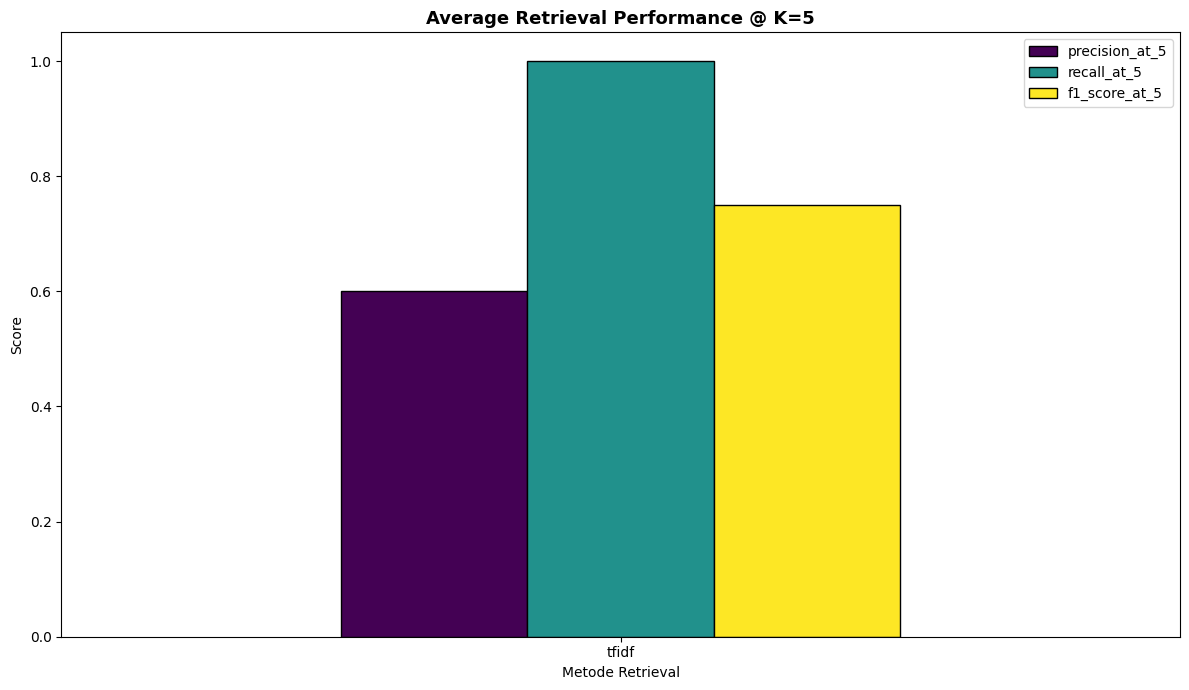

✅ Grafik retrieval disimpan ke: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/retrieval_performance_chart.png


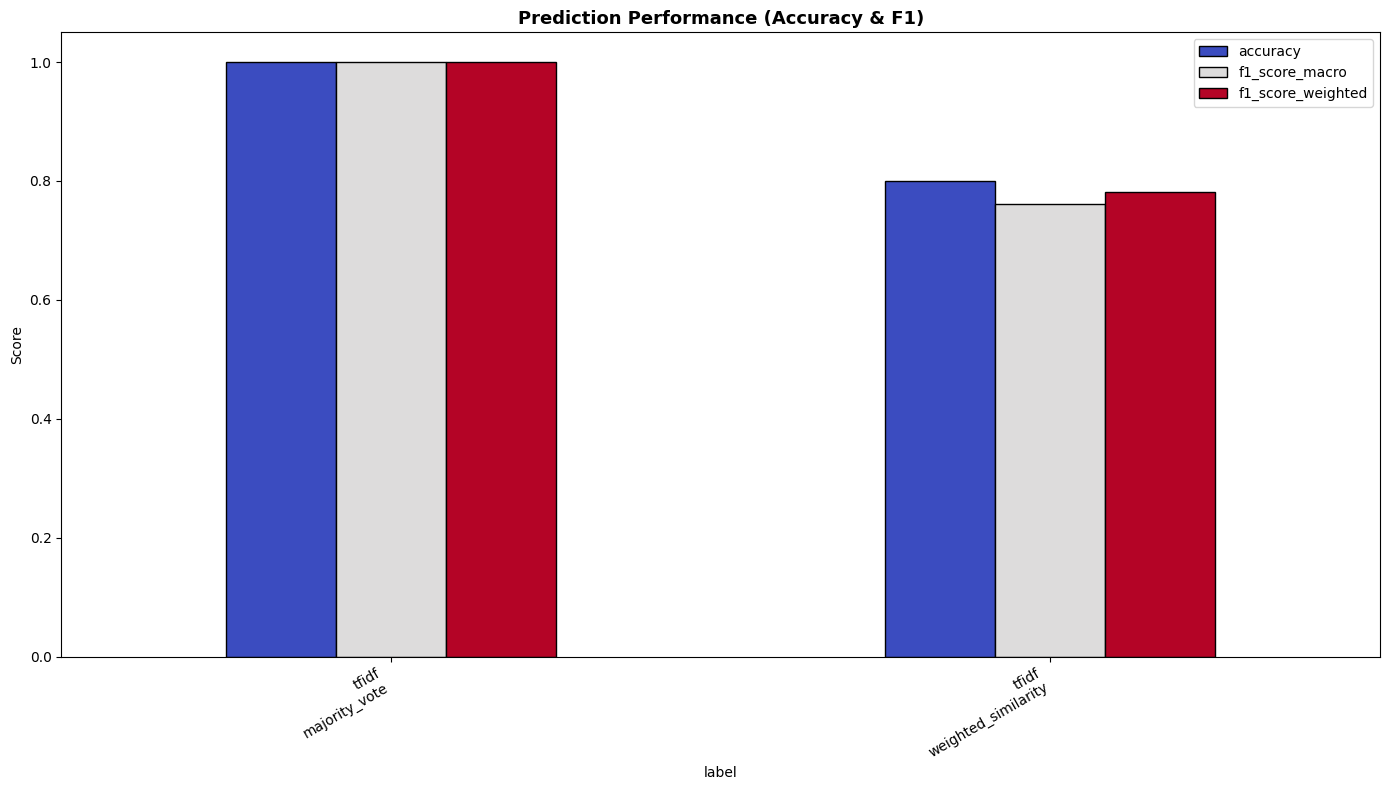

✅ Grafik prediksi disimpan ke: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/prediction_performance_chart.png

--- Analisis Kegagalan (Panduan Manual) ---
1. Buka retrieval_metrics_per_query.csv → filter query dengan skor rendah.
2. Bandingkan top_k_case_ids yang di-retrieve dengan ground_truth_ids.
3. Kemungkinan penyebab: query ambigu, mismatch kosakata (TF-IDF),
   keterbatasan BERT, atau kualitas teks PDF (OCR error, boilerplate).
4. Solusi: perbaiki preprocessing, query expansion, atau fine-tune BERT.
TAHAP 5: Model Evaluation — SELESAI

Tahap 5: Model Evaluation - Complete.


In [37]:
# --- Eksekusi Utama ---
if __name__ == "__main__":
    log_cleaning_action("=" * 60)
    log_cleaning_action("TAHAP 5: Model Evaluation — MULAI")
    log_cleaning_action("=" * 60)
    print("Starting Tahap 5: Model Evaluation")
#     drive.mount('/content/drive', force_remount=True)

    if load_data_for_evaluation():
        df_avg_ret_metrics = evaluate_retrieval_performance()
        df_pred_metrics = evaluate_prediction_performance() # This might return empty if no ground_truth_solution
        visualize_and_analyze(df_avg_ret_metrics, df_pred_metrics)
    else:
        print("Failed to load necessary data. Evaluation cannot proceed.")

    log_cleaning_action("TAHAP 5: Model Evaluation — SELESAI")
    print("\nTahap 5: Model Evaluation - Complete.")